# Location & relocation · Part A: the method, on a planted truth

**Where was the earthquake — and when a tenth of the arrival times are wrong and the velocity
model is wrong too, which part of that answer can you believe?**

Last week fitted a straight line and asked how much to believe it. The model was linear, the
answer came from one matrix solve, and the error bar came from the curvature of the likelihood.
This week keeps every one of those ideas and breaks the one assumption that made them easy:
**the model is no longer linear in what we want to know.**

An earthquake has four unknowns — where it was, $(x, y, z)$, and when it happened, $t_0$. What we
measure is the time a wave arrived at each seismometer. Those arrival times depend on the origin
time in the simplest possible way (later earthquake, later arrivals — a straight line of slope
one), and on the position in a thoroughly non-linear way, because moving the earthquake changes
the path the wave takes through a layered Earth.

That single complication is the whole session. It forces us to *iterate* rather than solve; it
makes the answer depend on where the iteration started; it means the error bar is a local
approximation to something that may not be a nice shape; and it opens a gap between two words
that week 1 could treat as synonyms — **precision** and **accuracy**.

## The questions this notebook answers

1. What is the forward problem, and what does the misfit surface look like? (A.1–A.2)
2. How do you solve a non-linear least-squares problem, and when does the standard method fail?
   (A.3–A.4)
3. What does the station geometry *allow* you to determine — what does it leave undetermined no
   matter how much data you collect, and what do you do about it? (A.5)
4. A tenth of real picks are badly wrong. Which loss function should you minimise, and how much
   does that choice matter compared with the choice of optimiser? (A.6–A.7)
5. Where does the error bar come from, and — the question that matters — **does it actually
   contain the truth?** (A.8–A.9)
6. If the velocity model is wrong, what can be repaired — and can you solve for the model
   itself? (A.10–A.11)
7. And where does machine learning enter a problem this classical? (A.12)

**Part A is synthetic, and that is a deliberate choice rather than a convenience.** Accuracy
cannot be measured against a catalogue, because a catalogue is *another estimate*, not the truth.
"Our locations agree closely with the network's" is a statement about agreement, and it would
read the same whether both were right or both were wrong in the same direction. The only place an error bar
can be put on trial is a world whose answer we set ourselves. So in Part A we plant the earthquake
and we know exactly what every method should recover.

What is *not* synthetic is the geometry: the seismometers are the real 2016 Geysers stations, at
their real positions and their real elevations. The world is wrong only where we choose to make it
wrong.

**[Part B](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/02b_location_geysers.ipynb)** is a separate notebook. It takes the identical code to
the real 2016 Geysers picks — the data the final project is built on — and asks whether every
conclusion below survives contact with data whose answer nobody knows. Each section here
therefore ends with the prediction it makes for that test, and A.12 collects all nine.


In [1]:
import importlib.util
import sys
import time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The course's modules sit beside the notebook on DataHub; Colab opens the notebook alone, so
# there they are fetched. `geysers_loc` is the travel-time and solver plumbing: the parts of this
# session you are asked to read and change are written out in cells below instead.
BASE = "https://raw.githubusercontent.com/AI4EPS/EPS207_Observational_Seismology/main/docs/notebooks"
for module in ("geysers_data.py", "geysers_loc.py"):
    if "google.colab" in sys.modules or importlib.util.find_spec(module[:-3]) is None:
        for attempt in range(4):
            try:
                urllib.request.urlretrieve(f"{BASE}/{module}", module)
                break
            except Exception as exc:
                if attempt == 3:
                    raise RuntimeError(f"could not fetch {module}: {exc}; re-run this cell") from None
                time.sleep(2 * (attempt + 1))

import geysers_loc as gl

rng = np.random.default_rng(207)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})


## A.1 · The forward problem: what a seismometer measures

Write the earthquake as $\mathbf{m} = (x, y, z, t_0)$ and the $i$-th station as
$(x_i, y_i, z_i)$. The wave leaves the earthquake at $t_0$, travels through the rock, and arrives
at

$$ t_i \;=\; T(x, y, z;\; x_i, y_i, z_i) \;+\; t_0 $$

where $T$ is the **travel time** — how long the fastest wave takes to get from the earthquake to
that station. Everything difficult about earthquake location lives inside $T$.

### What the Earth is made of, as far as $T$ is concerned

The real Earth is three-dimensional. Almost every routine location code, including the one that
produced the catalogue we will reproduce, replaces it with a stack of flat layers, each with its
own constant velocity. Inside a layer the ray is a straight line; at each boundary it bends,
according to Snell's law, so that

$$ p \;=\; \frac{\sin\theta}{v} \quad\text{is the same in every layer.}$$

That constant $p$ is the **ray parameter**, and it labels the ray. Fix $p$ and you have fixed the
whole path: the angle in each layer, the horizontal distance it covers, and the time it takes.

Two kinds of ray can arrive first. The **direct** ray goes straight up from the earthquake to the
station. The **head wave** dives to a faster layer below, runs along the top of it, and comes back
up — a longer path through faster rock, which wins beyond some distance. The first arrival is
whichever of the two is quicker, and the switch-over between them is a kink in the travel-time
curve that you can see.

We use the network's own model for this field: the NCSN Geysers model, which ships with
HYPOINVERSE as `gey.crh` and is the model of Eberhart-Phillips & Oppenheimer (1984,
[10.1029/JB089iB02p01191](https://doi.org/10.1029/JB089iB02p01191)). Later we will also use
**GIL7**, the model northern California moment tensors are computed in, which is *wrong* here —
and measuring what that costs is one of the points of the session.


In [2]:
top, v = gl.layers(gl.GEY, "P")
print("The NCSN Geysers P model (depth below sea level, km, and Vp in km/s):")
for a, b, vel in zip(top[:-1], top[1:], v):
    print(f"  {a:6.2f} to {b:6.2f} km   Vp {vel:.2f}")
print(f"\nVp/Vs is {gl.VPVS}, so the S model is the same layers with every velocity divided by it.")


The NCSN Geysers P model (depth below sea level, km, and Vp in km/s):
    0.00 to   1.50 km   Vp 4.43
    1.50 to   3.00 km   Vp 5.12
    3.00 to   4.25 km   Vp 5.47
    4.25 to   6.00 km   Vp 5.58
    6.00 to   8.00 km   Vp 5.62
    8.00 to  21.00 km   Vp 5.86
   21.00 to  81.00 km   Vp 7.90

Vp/Vs is 1.78, so the S model is the same layers with every velocity divided by it.


### The travel-time curve

Here is $T$ for one source depth, as a function of distance, with the two branches separated. The
kink is where the head wave overtakes the direct ray. The slope of the curve at any distance *is*
the ray parameter $p$ — a fact we are about to need, because it turns out to be exactly what the
derivative of the travel time with respect to position is made of.


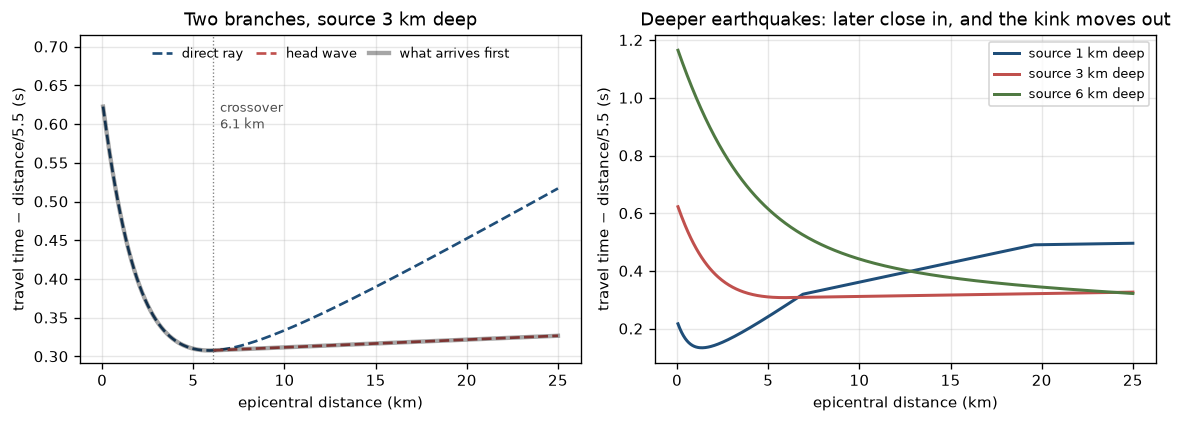

In [3]:
def head_time(top, v, zs, r, zr=0.0):
    """The quickest head wave, or nan where none reaches this distance."""
    branches = gl.head(top, v, zs, r, zr)
    return min((t for t, _ in branches), default=np.nan)


# Curves are drawn "reduced" -- travel time minus distance/5.5 km/s. Subtracting a straight
# line costs no information and turns two nearly-parallel lines into two clearly different
# curves, which is the only way the crossover is visible at all.
V_RED = 5.5
r = np.linspace(0.05, 25.0, 500)
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.6))

zs0 = 3.0
t_direct = np.array([gl.direct(top, v, zs0, ri, 0.0)[0] for ri in r])
t_head = np.array([head_time(top, v, zs0, ri, 0.0) for ri in r])
t_first = np.fmin(t_direct, np.where(np.isfinite(t_head), t_head, np.inf))
ax[0].plot(r, t_direct - r / V_RED, c="#1f4e79", lw=1.6, ls="--", label="direct ray")
ax[0].plot(r, t_head - r / V_RED, c="#c0504d", lw=1.6, ls="--", label="head wave")
ax[0].plot(r, t_first - r / V_RED, c="k", lw=2.6, alpha=0.35, label="what arrives first")
xo = r[np.nanargmin(np.abs(t_direct - t_head))]
ax[0].axvline(xo, c="0.5", lw=0.8, ls=":")
# Open a band of headroom above every curve and put the legend there. Anywhere inside the axes
# it would sit on top of the head-wave branch, which is the thing the panel exists to show.
lo, hi = ax[0].get_ylim()
ax[0].set_ylim(lo, hi + 0.22 * (hi - lo))
ax[0].annotate(f"crossover\n{xo:.1f} km", (xo, hi), xytext=(4, -4),
               textcoords="offset points", va="top", fontsize=7.5, color="0.3")
ax[0].set(xlabel="epicentral distance (km)", ylabel=f"travel time − distance/{V_RED} (s)",
          title=f"Two branches, source {zs0:.0f} km deep")
ax[0].legend(fontsize=7.5, loc="upper center", ncol=3, framealpha=0.0,
             handlelength=1.6, columnspacing=1.0)

for zs, c in ((1.0, "#1f4e79"), (3.0, "#c0504d"), (6.0, "#4f7942")):
    tf = np.array([gl.first(top, v, zs, ri, 0.0)[0] for ri in r])
    ax[1].plot(r, tf - r / V_RED, c=c, lw=1.8, label=f"source {zs:.0f} km deep")
ax[1].set(xlabel="epicentral distance (km)", ylabel=f"travel time − distance/{V_RED} (s)",
          title="Deeper earthquakes: later close in, and the kink moves out")
ax[1].legend(fontsize=7.5, loc="upper right")
fig.tight_layout()
plt.show()


## A.2 · One planted earthquake

Now we choose an earthquake and compute what the network would have recorded. The stations are
the real 2016 Geysers stations; the earthquake is ours.

Two features of this network matter later and are worth noticing now. The stations span more than
a kilometre of **topography** — this is a mountainous geothermal field — and the earthquakes are
*shallow*, so a station can easily be higher above sea level than the earthquake is below it. And
the network is **dense**: the nearest station is often closer than the earthquake is deep.


In [4]:
# A real Geysers earthquake of the size the catalogue is made of is picked at a dozen or so
# stations, not at every station in the field.  Part A keeps the same number, so that what we
# conclude here is a fair prediction of what Part B will find on the real picks.
N_STA = 20
_all = gl.stations_2016(within=15.0)
st = _all.iloc[np.argsort(np.hypot(_all.x - 1.2, _all.y - 0.8).to_numpy())[:N_STA]].reset_index(drop=True)

# The travel-time tables: one grid of source depth by receiver depth by distance, per phase.
# Building them once here is what makes every later locate call cheap.
ZS = np.arange(-2.5, 9.001, 0.1)                # source depth, km below sea level
ZR = np.arange(float(_all.z.min()) - 0.1, float(_all.z.max()) + 0.1001, 0.1)   # station depth
RR = np.arange(0.0, 30.001, 0.05)               # epicentral distance
tabs = [gl.build(gl.GEY, ph, ZR, ZS, RR) for ph in ("P", "S")]        # the right model
tabs_gil7 = [gl.build(gl.GIL7, ph, ZR, ZS, RR) for ph in ("P", "S")]  # the wrong one, from A.9 on

TRUTH = np.array([1.2, 0.8, 2.0, 0.0])          # x east, y north, z down from sea level, t0
NOISE = 0.03                                    # the analyst's reading error, seconds
sta, t_obs, phase, _ = gl.observe(TRUTH, st, tabs, noise=NOISE, seed=1)

print(f"{len(st)} stations, elevations {-st.z.max():.2f} to {-st.z.min():.2f} km above sea level")
print(f"the planted earthquake: x {TRUTH[0]:.2f} km, y {TRUTH[1]:.2f} km, "
      f"depth {TRUTH[2]:.2f} km below sea level, origin time {TRUTH[3]:.2f} s")
d = np.hypot(TRUTH[0] - sta[:, 0], TRUTH[1] - sta[:, 1])
az = np.degrees(np.arctan2(sta[:, 0] - TRUTH[0], sta[:, 1] - TRUTH[1])) % 360
gap = np.max(np.diff(np.concatenate([np.sort(az), [np.sort(az)[0] + 360]])))
print(f"{len(sta)} picks; nearest station {d.min():.2f} km, furthest {d.max():.2f} km; "
      f"largest azimuthal gap {gap:.0f} degrees")
# A station closer than the earthquake is deep sees a steeply rising ray, and that is what
# separates depth from origin time.  A.5 shows why; here, just count them.
print(f"{int(np.sum(d < TRUTH[2]))} of {len(sta)} stations are closer than the focal depth "
      f"of {TRUTH[2]:.1f} km")
print(f"reading error put into the arrival times: {NOISE} s")


20 stations, elevations 0.33 to 1.29 km above sea level
the planted earthquake: x 1.20 km, y 0.80 km, depth 2.00 km below sea level, origin time 0.00 s
20 picks; nearest station 0.69 km, furthest 4.25 km; largest azimuthal gap 46 degrees
5 of 20 stations are closer than the focal depth of 2.0 km
reading error put into the arrival times: 0.03 s


### The misfit surface

Locating the earthquake means finding the $\mathbf{m}$ whose predicted arrival times best match
the observed ones. "Best" needs a definition, and the obvious one is week 1's: minimise the sum of
squared differences,

$$ F(\mathbf{m}) \;=\; \sum_i \bigl[\, t_i^{\text{obs}} - T_i(\mathbf{m}) - t_0 \,\bigr]^2 .$$

Before running any clever method, look at the thing being minimised. Because $t_0$ enters
linearly, at any trial position the best origin time is just the average of what is left over, so
we can profile it out and draw the misfit over the three *spatial* unknowns. Below are slices
through that volume at the true depth and through the true epicentre.

This picture is the honest reason the rest of the session is not trivial. In week 1 the misfit was
an exact paraboloid with one minimum and a formula for it. Here it is a curved valley, and while
the epicentre is sharply defined, **depth is not**: the valley runs almost straight down.


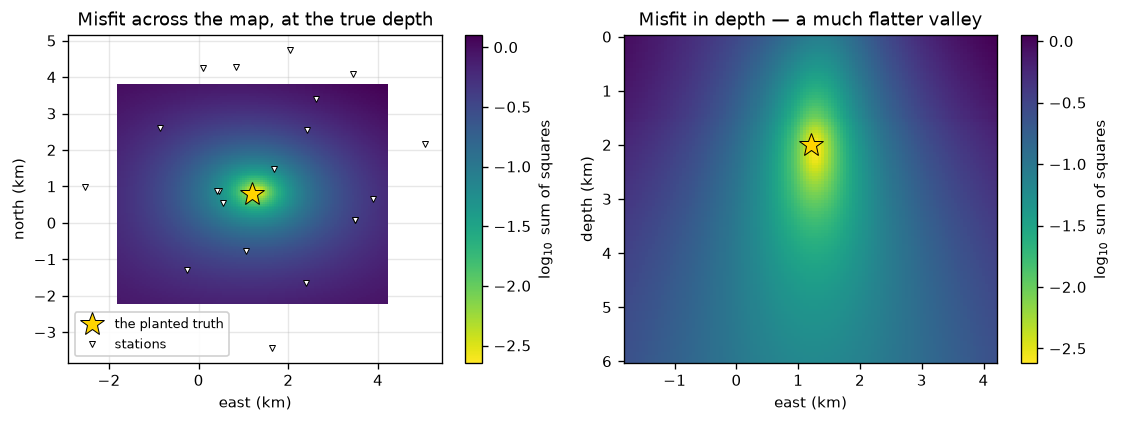

In [5]:
def misfit_grid(sta, t_obs, phase, tabs, gx, gy, z, loss="l2"):
    """Sum of squares over a plane of trial epicentres, with the origin time profiled out."""
    F = np.empty((len(gy), len(gx)))
    for j, y in enumerate(gy):
        r = np.maximum(np.hypot(np.subtract.outer(gx, sta[:, 0]), y - sta[:, 1]), 1e-3)
        t = np.empty_like(r)
        for ph in (0, 1):
            s = phase == ph
            if s.any():
                t[:, s] = gl.predict(tabs[ph], np.broadcast_to(sta[s, 2], (len(gx), int(s.sum()))),
                                     z, r[:, s])[0]
        dd = t_obs - t
        F[j] = np.sum(gl.rho(dd - dd.mean(axis=1, keepdims=True), loss), axis=1)
    return F


gx = np.linspace(TRUTH[0] - 3.0, TRUTH[0] + 3.0, 121)
gy = np.linspace(TRUTH[1] - 3.0, TRUTH[1] + 3.0, 121)
gz = np.linspace(0.0, 6.0, 121)

F_xy = misfit_grid(sta, t_obs, phase, tabs, gx, gy, TRUTH[2])
F_xz = np.array([misfit_grid(sta, t_obs, phase, tabs, gx, np.array([TRUTH[1]]), z)[0] for z in gz])

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
m0 = ax[0].pcolormesh(gx, gy, np.log10(F_xy), cmap="viridis_r", shading="auto")
ax[0].plot(*TRUTH[:2], "*", ms=15, mfc="#ffd400", mec="k", mew=0.6, label="the planted truth")
ax[0].plot(sta[:, 0], sta[:, 1], "v", ms=4, mfc="w", mec="k", mew=0.6, label="stations")
ax[0].set(xlabel="east (km)", ylabel="north (km)", title="Misfit across the map, at the true depth")
ax[0].legend(fontsize=7.5, loc="lower left", framealpha=0.9)
fig.colorbar(m0, ax=ax[0], label=r"$\log_{10}$ sum of squares")

m1 = ax[1].pcolormesh(gx, gz, np.log10(F_xz), cmap="viridis_r", shading="auto")
ax[1].plot(TRUTH[0], TRUTH[2], "*", ms=15, mfc="#ffd400", mec="k", mew=0.6)
ax[1].invert_yaxis()
ax[1].set(xlabel="east (km)", ylabel="depth (km)", title="Misfit in depth — a much flatter valley")
fig.colorbar(m1, ax=ax[1], label=r"$\log_{10}$ sum of squares")
fig.tight_layout()
plt.show()


### The grid search: the method that cannot go wrong, and cannot scale

One way to find the minimum is to evaluate the misfit everywhere and keep the best node. It has a
genuine virtue that no iterative method has: **it sees the whole surface**, so it cannot be
trapped by a local minimum or misled by a bad starting guess. That is why we will keep using it —
not as the production method, but as the honest reference that tells us when a faster method has
failed.

Its defect is arithmetic. The cost grows as the cube of the resolution, and the answer is only ever
as good as the node spacing.


In [6]:
t0 = time.time()
g = gl.grid_search(sta, t_obs, phase, tabs, half=8.0, step=0.25, zstep=0.25)
dt_grid = time.time() - t0
print(f"grid search      x {g[0]:7.3f}  y {g[1]:7.3f}  z {g[2]:7.3f}  t0 {g[3]:+7.3f}   [{dt_grid:.1f} s]")
print(f"the planted truth x {TRUTH[0]:7.3f}  y {TRUTH[1]:7.3f}  z {TRUTH[2]:7.3f}  t0 {TRUTH[3]:+7.3f}")
print(f"\nerror {1000 * np.linalg.norm(g[:3] - TRUTH[:3]):.0f} m, which is about the node spacing "
      f"of {1000 * 0.25:.0f} m, as it must be.")
n_nodes = (2 * 8.0 / 0.25) ** 2 * (9.0 / 0.25)
print(f"it evaluated roughly {n_nodes:,.0f} nodes; halving the spacing would cost eight times more.")


grid search      x   1.343  y   0.823  z   2.000  t0  +0.001   [0.6 s]
the planted truth x   1.200  y   0.800  z   2.000  t0  +0.000

error 145 m, which is about the node spacing of 250 m, as it must be.
it evaluated roughly 147,456 nodes; halving the spacing would cost eight times more.


## A.3 · Geiger's method: make it linear, solve, and do it again

The misfit surface is not a paraboloid, so there is no formula for its minimum. But it is
*smooth*, and near any trial hypocentre it looks like a paraboloid. That is the whole idea, and it
is more than a century old — Geiger proposed it in 1910–1912 and every routine location program
since, HYPO71 and HYPOINVERSE included, is a version of it.

Here is the whole derivation, one step at a time. Nothing in it is harder than a first Taylor
expansion, but every symbol matters, so none of them is introduced without being said what it is.

**The setup.** Collect the four unknowns into one vector,

$$\mathbf{m} \;=\; (x,\; y,\; z,\; t_0),$$

and let $T_i(x, y, z)$ be the travel time from that trial hypocentre to station $i$ — the
quantity A.1 computed. Note that $T_i$ does **not** depend on $t_0$; the origin time only shifts
the arrival. So the arrival time this guess predicts at station $i$ is $T_i(x,y,z) + t_0$, and
the **residual** is what the real measurement has left over once the prediction is subtracted:

$$ r_i \;=\; t_i^{\text{obs}} \;-\; T_i(x, y, z) \;-\; t_0 .$$

With a perfect guess and noise-free picks every $r_i$ would be zero. They are not. So we look for
a **correction**

$$\Delta\mathbf{m} \;=\; (\Delta x,\; \Delta y,\; \Delta z,\; \Delta t_0)$$

that makes them smaller. From here on $\Delta\mathbf{m}$ is the only unknown — the four numbers
we are solving for.

**Step 1. Write the residual at the corrected hypocentre.** Move the guess by $\Delta\mathbf{m}$
and recompute the same expression:

$$ r_i^{\text{new}} \;=\; t_i^{\text{obs}} \;-\;
   T_i(x + \Delta x,\; y + \Delta y,\; z + \Delta z) \;-\; (t_0 + \Delta t_0).$$

We cannot solve this for $\Delta\mathbf{m}$, because $T_i$ is the awkward non-linear function
this whole session is about. So we approximate it.

**Step 2. Taylor-expand the travel time and keep only the linear term.** For a small enough move,

$$ T_i(x + \Delta x, y + \Delta y, z + \Delta z) \;\approx\; T_i(x, y, z)
   \;+\; \frac{\partial T_i}{\partial x}\,\Delta x
   \;+\; \frac{\partial T_i}{\partial y}\,\Delta y
   \;+\; \frac{\partial T_i}{\partial z}\,\Delta z .$$

**This is the only approximation in the method**, and everything awkward in A.4 follows from it:
it holds only while $\Delta\mathbf{m}$ is small.

**Step 3. Substitute it back.** Put Step 2 into Step 1. The unchanged part is exactly the old
residual $r_i$, and what is subtracted from it is the four correction terms — with a coefficient
of $1$ on $\Delta t_0$, because the origin time shifts every arrival by itself:

$$ r_i^{\text{new}} \;\approx\; r_i \;-\;
   \left[\;\frac{\partial T_i}{\partial x}\Delta x
        + \frac{\partial T_i}{\partial y}\Delta y
        + \frac{\partial T_i}{\partial z}\Delta z
        + 1\cdot\Delta t_0\;\right].$$

**Step 4. Name the bracket.** The four derivatives in it are just four numbers once the trial
hypocentre is fixed, one per unknown, and they belong to station $i$. Call that row of four
numbers $\mathbf{G}_i$:

$$ \mathbf{G}_i \;=\; \left[\;\frac{\partial T_i}{\partial x},\;\;
     \frac{\partial T_i}{\partial y},\;\; \frac{\partial T_i}{\partial z},\;\; 1\;\right].$$

The bracket is then the dot product $\mathbf{G}_i \cdot \Delta\mathbf{m}$, and Step 3 reads
$r_i^{\text{new}} \approx r_i - \mathbf{G}_i \cdot \Delta\mathbf{m}$. That is all $\mathbf{G}_i$
is: **how much station $i$'s predicted arrival time moves, per unit move of each unknown.**

**Step 5. Ask for the corrected residuals to vanish — at every station at once.** Setting
$r_i^{\text{new}} = 0$ gives one equation per pick:

$$ \mathbf{G}_i \cdot \Delta\mathbf{m} \;=\; r_i, \qquad i = 1, \ldots, n.$$

Now stack them. Lay the rows $\mathbf{G}_1, \ldots, \mathbf{G}_n$ one under another to make a
matrix $\mathbf{G}$ with **one row per pick and one column per unknown** — so $\mathbf{G}$ is
$n \times 4$ — and collect the residuals into a vector $\mathbf{r}$ of length $n$. Those $n$
separate equations are one matrix equation:

$$ \mathbf{G}\,\Delta\mathbf{m} \;=\; \mathbf{r} .$$

**Step 6. Recognise what we have built.** There are $n$ equations and only 4 unknowns, and $n$ is
a dozen or more, so the system is overdetermined and has no exact solution — no single hypocentre
explains every pick perfectly. The least-squares answer is week 1's normal equations, with
$\mathbf{G}$ sitting exactly where week 1's design matrix sat:

$$ \mathbf{G}^{\mathsf T}\mathbf{G}\,\Delta\mathbf{m} \;=\; \mathbf{G}^{\mathsf T}\mathbf{r}.$$

**Step 7. Take the step, then do the whole thing again.** Update $\mathbf{m} \leftarrow
\mathbf{m} + \Delta\mathbf{m}$. Because Step 2 was only an approximation, the new residuals will
not really be zero — but they should be smaller. So recompute them, rebuild $\mathbf{G}$ at the
new hypocentre (the derivatives have changed, since we moved), and solve again.

**Non-linear least squares is linear least squares, done repeatedly.**

### The four columns of $\mathbf{G}$, and what they mean

This is the part worth slowing down for, because each column has a physical reading.

Step 4 named the derivatives without saying what they are. Here they are. Let $d$ be the
horizontal distance from earthquake to station — written $d$ rather than $r$ so it is not
confused with the residuals above — and let $p$ be the ray parameter, the slope of the
travel-time curve we plotted in A.1. Then

$$\frac{\partial T}{\partial x} = p\,\frac{x - x_i}{d}, \qquad
  \frac{\partial T}{\partial y} = p\,\frac{y - y_i}{d}, \qquad
  \frac{\partial T}{\partial z} = \pm\eta, \qquad
  \frac{\partial T}{\partial t_0} = 1 .$$

The first two say: moving the earthquake horizontally changes the travel time by the **horizontal
slowness** times how much of that move was along the ray. The third involves
$\eta = \sqrt{1/v^2 - p^2}$, the **vertical slowness** — and its *sign* is the direction the ray
left the source. A ray that leaves downward, as a head wave does, is delayed by moving the source
down; a ray that leaves upward is advanced. Getting that sign wrong is not a rounding error, it
points the depth correction the wrong way.

**Those same two numbers are next week's input, which is worth naming while we have them.**
Together $p$ and $\eta$ fix the direction the ray left the earthquake — $\sin(\text{take-off
angle}) = p\,v$ at the source, with the sign of $\eta$ saying whether it set off upward or
downward. That angle contributes nothing to locating the earthquake, but it is the *only* thing
session 3 needs from a hypocentre, because a focal mechanism is read from which quadrant of the
focal sphere each station sits in as seen from the source. A location code gets take-off angles
for free while it is filling this column, which is why catalogues ship them beside the
hypocentre and why next week begins where this week ends.

The fourth column is a column of **ones**, and it is the source of everything awkward in this
session: every arrival time is shifted equally by the origin time. Hold that thought until A.5.


In [7]:
def jacobian(m, sta, phase, tabs):
    """One row of G per pick: how much that arrival time moves per unit move of each unknown.

    Columns, in the order of m = (x, y, z, t0): dT/dx, dT/dy, dT/dz, and a column of ones.
    `d` is the horizontal source-receiver distance, `p` the ray parameter and `eta` the vertical
    slowness; the travel-time table stores p and eta alongside the time itself, so the
    derivatives cost nothing extra.
    """
    dx, dy = m[0] - sta[:, 0], m[1] - sta[:, 1]
    d = np.maximum(np.hypot(dx, dy), 1e-3)
    t = np.empty_like(d)
    p = np.empty_like(d)
    eta = np.empty_like(d)
    for ph in (0, 1):
        s = phase == ph
        if s.any():
            t[s], p[s], eta[s] = gl.predict(tabs[ph], sta[s, 2], m[2], d[s])
    G = np.column_stack([p * dx / d, p * dy / d, eta, np.ones_like(d)])
    return t, G


Before iterating, look at the matrix itself for the planted earthquake. Each row is one pick;
the numbers are seconds per kilometre.


In [8]:
_t, G0 = jacobian(TRUTH, sta, phase, tabs)
print(f"{'':6}{'dT/dx':>9}{'dT/dy':>9}{'dT/dz':>9}{'dT/dt0':>9}   (s per km, s per s)")
for i in range(4):
    print(f"pick {i}{G0[i, 0]:9.4f}{G0[i, 1]:9.4f}{G0[i, 2]:9.4f}{G0[i, 3]:9.4f}")
print(f"... {len(G0) - 4} more picks")
print(f"\nthe last column is exactly 1 for every pick: every arrival is shifted equally by t0")
print(f"the third column varies from {G0[:, 2].min():.3f} to {G0[:, 2].max():.3f}, and A.5 shows")
print("that this variation is the only thing that separates depth from origin time")


          dT/dx    dT/dy    dT/dz   dT/dt0   (s per km, s per s)
pick 0   0.0470   0.0176   0.1887   1.0000
pick 1   0.0544  -0.0047   0.1875   1.0000
pick 2   0.0572  -0.0062   0.1866   1.0000
pick 3  -0.0324  -0.0461   0.1870   1.0000
... 16 more picks

the last column is exactly 1 for every pick: every arrival is shifted equally by t0
the third column varies from 0.072 to 0.189, and A.5 shows
that this variation is the only thing that separates depth from origin time


Now the iteration itself: solve, step, relinearise, repeat.


In [9]:
def geiger_method(sta, t_obs, phase, tabs, m0, lam=0.0, iters=20, zlim=None):
    """Geiger's method: linearise, solve, step, repeat.

    `lam` is the damping of A.4; lam=0 is plain Gauss-Newton. Returns the path taken, so the
    iteration can be watched rather than just its answer reported.
    """
    lo, hi = (float(tabs[0]["zs"].min()), float(tabs[0]["zs"].max())) if zlim is None else zlim
    m = np.array(m0, float)
    path = [m.copy()]
    for _ in range(iters):
        t, G = jacobian(m, sta, phase, tabs)
        res = t_obs - t - m[3]
        A = G.T @ G
        try:
            step = np.linalg.solve(A + lam * np.diag(np.diag(A) + 1e-12), G.T @ res)
        except np.linalg.LinAlgError:
            # With lam = 0 this really does happen: G'G goes singular and there is no step to
            # take. Reporting it as a failure is more honest than hiding it behind a pseudo-
            # inverse, because in production it is a lost earthquake either way.
            return m, np.array(path), False
        m = m + step
        m[2] = np.clip(m[2], lo, hi)
        path.append(m.copy())
        if np.max(np.abs(step[:3])) < 1e-6:
            break
    return m, np.array(path), True


Run it from a deliberately poor starting guess — the middle of the network, 5 km down — and
watch the steps collapse.


In [10]:
m_fit, path, _ = geiger_method(sta, t_obs, phase, tabs, m0=[0.0, 0.0, 5.0, 0.0])
print("Geiger's method from a deliberately poor start (0, 0, 5 km):")
print(f"  {'iter':>4}  {'x':>8} {'y':>8} {'z':>8} {'t0':>8}   {'step (m)':>9}")
for i, mm in enumerate(path[:9]):
    s = "" if i == 0 else f"{1000 * np.linalg.norm(path[i][:3] - path[i - 1][:3]):9.1f}"
    print(f"  {i:4d}  {mm[0]:8.3f} {mm[1]:8.3f} {mm[2]:8.3f} {mm[3]:+8.3f}   {s:>9}")
print(f"  ... converged in {len(path) - 1} iterations")
print(f"\n  truth    {TRUTH[0]:8.3f} {TRUTH[1]:8.3f} {TRUTH[2]:8.3f} {TRUTH[3]:+8.3f}")
print(f"  error {1000 * np.linalg.norm(m_fit[:3] - TRUTH[:3]):.0f} m")


Geiger's method from a deliberately poor start (0, 0, 5 km):
  iter         x        y        z       t0    step (m)
     0     0.000    0.000    5.000   +0.000            
     1     2.269    1.446    0.423   +0.344      5309.2
     2     1.563    1.004    2.251   +0.031      2008.4
     3     1.266    0.839    2.063   -0.002       388.2
     4     1.276    0.844    2.057   -0.004        13.3
     5     1.276    0.844    2.057   -0.004         0.3
     6     1.276    0.844    2.057   -0.004         0.0
     7     1.276    0.844    2.057   -0.004         0.0
  ... converged in 7 iterations

  truth       1.200    0.800    2.000   +0.000
  error 105 m


Two things are worth reading off that table. The steps shrink fast — this is the quadratic-ish
convergence that makes Gauss–Newton worth using, and it is why a production code needs only a
handful of iterations per earthquake rather than the hundred thousand grid nodes of A.2. And the
answer it settles on is about a hundred metres from the truth — which is *not* the method
stopping short. It is the reading noise we put into the arrival times, propagated through this
particular arrangement of stations, and no method minimising this objective on this data can do
better. A.5 measures that floor directly.

### Checking our cell against the reference implementation

`geiger_method` above is the version you are asked to read. The module's `locate` is the one used
for the production runs later, and it has been checked against HypoDD's Fortran and against ADLoc.
They should agree; if they ever stop agreeing, one of them is wrong.


In [11]:
ref = gl.locate(sta, t_obs, phase, tabs, x0=[0.0, 0.0, 5.0, 0.0])
print(f"our cell : {np.round(m_fit, 4)}")
print(f"reference: {np.round(ref['m'], 4)}")
print(f"they differ by {1000 * np.linalg.norm(m_fit[:3] - ref['m'][:3]):.2f} m")


our cell : [ 1.2763  0.8442  2.0572 -0.0042]
reference: [ 1.2763  0.8442  2.0572 -0.0042]
they differ by 0.00 m


## A.4 · Why plain Gauss–Newton is not enough, and what damping is

The linearisation is only good near the current point. If the step it suggests is large, it walks
out of the region where the approximation held and can easily land somewhere *worse* than it
started. Two things provoke this: a poor starting guess, and a nearly-singular
$\mathbf{G}^{\mathsf T}\mathbf{G}$ — which, as A.5 will show, is the normal state of affairs for
earthquake depth.

The fix is **Levenberg–Marquardt**: add a positive number $\lambda$ to the diagonal before solving,

$$ (\mathbf{G}^{\mathsf T}\mathbf{G} + \lambda\,\mathrm{diag}(\mathbf{G}^{\mathsf T}\mathbf{G}))\,
   \Delta\mathbf{m} \;=\; \mathbf{G}^{\mathsf T}\mathbf{r} .$$

**You have already met this formula.** It is week 1's ridge regression, with $\lambda$ in exactly
the same place. The interpretation is different, though, and the difference is worth stating
plainly:

| | week 1, ridge | here, Levenberg–Marquardt |
|---|---|---|
| what $\lambda$ multiplies | the model itself | the *step* |
| what it expresses | a prior: coefficients are small | a trust region: do not go far from a point where I trust the linearisation |
| how it is chosen | once, by cross-validation | adaptively, every iteration |

Why does adding to the diagonal shorten the step? Take the two limits of that equation.

With $\lambda = 0$ it is A.3's normal equation unchanged, so $\Delta\mathbf{m}$ is the full
Gauss–Newton step — however long that is. As $\lambda$ grows, the added term eventually dwarfs
$\mathbf{G}^{\mathsf T}\mathbf{G}$, and the equation tends to
$\lambda\,\mathrm{diag}(\mathbf{G}^{\mathsf T}\mathbf{G})\,\Delta\mathbf{m} =
\mathbf{G}^{\mathsf T}\mathbf{r}$, whose solution is

$$ \Delta\mathbf{m} \;\approx\; \frac{1}{\lambda}\,
   \mathrm{diag}(\mathbf{G}^{\mathsf T}\mathbf{G})^{-1}\,\mathbf{G}^{\mathsf T}\mathbf{r}.$$

Two things to read off it. The $1/\lambda$ says the step gets **shorter** as $\lambda$ grows, as
much as we like. And $\mathbf{G}^{\mathsf T}\mathbf{r}$ is the downhill direction of the misfit,
so what is left is a short move straight downhill — gradient descent. In between, $\lambda$
slides continuously between the two. A practical code starts small, and whenever a step
fails to reduce the misfit it *raises* $\lambda$ and tries again — which is what the module's
`locate` does, and what the next figure shows the need for.


In [12]:
starts = [(0.0, 0.0, 5.0), (-6.0, 5.0, 0.5), (8.0, -6.0, 8.0), (4.0, 4.0, 0.0)]
def shown(m, ok):
    return "  broke down" if not ok else f"{1000 * np.linalg.norm(m[:3] - TRUTH[:3]):8.0f} m"


print(f"{'start (x, y, z)':>22} {'plain Gauss-Newton':>22} {'damped, lambda=1e-2':>22}")
for s in starts:
    a, _, oka = geiger_method(sta, t_obs, phase, tabs, m0=[*s, 0.0], lam=0.0)
    b, _, okb = geiger_method(sta, t_obs, phase, tabs, m0=[*s, 0.0], lam=1e-2)
    print(f"{str(tuple(s)):>22} {shown(a, oka):>22} {shown(b, okb):>22}")


       start (x, y, z)     plain Gauss-Newton    damped, lambda=1e-2
       (0.0, 0.0, 5.0)                  105 m                  105 m
      (-6.0, 5.0, 0.5)          25335965741 m                  105 m
      (8.0, -6.0, 8.0)           1292295928 m                  105 m
       (4.0, 4.0, 0.0)                 4539 m                  105 m


Now the same comparison over many random starting points, which is the honest way to ask how
often a method fails rather than whether it failed once.


300 random starting points, spread over the whole field and 0-8 km depth:

                            median error  within 100 m  worse than 1 km   broke down
plain Gauss-Newton          1139117821 m           0 %              79 %         81
damped, lambda = 1e-2              105 m           0 %               1 %          0
the module's adaptive LM           105 m           0 %               3 %          0


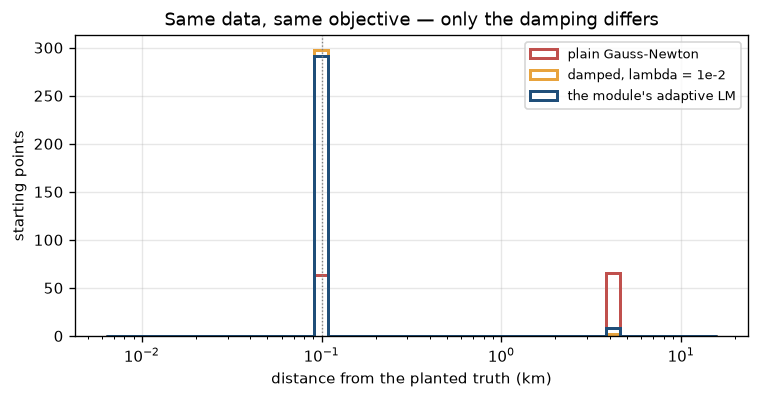

In [13]:
n_try = 300
g0 = rng.uniform([-8, -8, 0.0], [8, 8, 8.0], size=(n_try, 3))
err = {"plain Gauss-Newton": [], "damped, lambda = 1e-2": [], "the module's adaptive LM": []}
broke = {k: 0 for k in err}
for s in g0:
    a, _, oka = geiger_method(sta, t_obs, phase, tabs, m0=[*s, 0.0], lam=0.0)
    b, _, okb = geiger_method(sta, t_obs, phase, tabs, m0=[*s, 0.0], lam=1e-2)
    c = gl.locate(sta, t_obs, phase, tabs, x0=[*s, 0.0])["m"]
    for k, m, ok in zip(err, (a, b, c), (oka, okb, True)):
        err[k].append(np.linalg.norm(m[:3] - TRUTH[:3]) if ok else np.inf)
        broke[k] += 0 if ok else 1

print(f"{n_try} random starting points, spread over the whole field and 0-8 km depth:\n")
print(f"{'':26}{'median error':>14}{'within 100 m':>14}{'worse than 1 km':>17}{'broke down':>13}")
for k, e in err.items():
    e = np.array(e)
    med = f"{1000 * np.median(e):8.0f} m" if np.isfinite(np.median(e)) else "     --  "
    print(f"{k:26}{med:>14}{100 * np.mean(e < 0.1):12.0f} % {100 * np.mean(e > 1.0):15.0f} %"
          f"{broke[k]:11d}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
bins = np.logspace(-2.2, 1.2, 45)
for k, c in zip(err, ("#c0504d", "#e8a33d", "#1f4e79")):
    ax.hist(np.clip(err[k], 1e-2, None), bins=bins, histtype="step", lw=1.8, label=k, color=c)
ax.axvline(0.1, c="0.5", lw=0.8, ls=":")
ax.set(xscale="log", xlabel="distance from the planted truth (km)", ylabel="starting points",
       title="Same data, same objective — only the damping differs")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


**The large effect is in the first row, and it is the point of the section.** Without damping,
four starts in five end more than a kilometre from the truth and a quarter fail outright. With
it, essentially none do. That is not a numerical nicety; it is the difference between a locator
that works and one that does not.

The gap between the two damped schemes is much smaller — both succeed about ninety-nine times in
a hundred — but it is real and worth one sentence. The module's adaptive scheme, which starts
with little damping and raises it only when a step fails, is what production codes do, and here
it lands in the wrong place a few times more often than the fixed $\lambda$: it is willing to
take a long first step, and from a bad enough start that step can cross into a different valley.
The ordering is stable rather than a fluke of one draw — repeating the whole experiment with
fresh sets of starting points reproduces it every time. It does not make the adaptive scheme a
poor choice, because no single $\lambda$ suits every event in a real catalogue; it makes the
point that **tuning the damping is not what rescues a bad start.**

**What rescues a bad start is not starting badly**, and that is the conclusion Part B re-tests.
A.2's grid search stays in the workflow: it is slow, it cannot be fooled, and it supplies a
starting point the fast method can safely refine. Every production locator in this field —
HYPOINVERSE, HypoDD, ADLoc — is exactly this pairing, a coarse search followed by a damped
iteration.

It is also the first instance of a pattern that will repeat: **the objective and the algorithm
are separate choices.** All three rows above minimise the identical sum of squares. They disagree
only because they search it differently. In A.6 we change the objective instead, and see a much
larger effect.


## A.5 · What the geometry determines — and what it never will

So far the difficulty has been the *algorithm*. This section is about a difficulty no algorithm
can remove. Some combinations of the four unknowns are simply not visible in the data, and which
ones depends entirely on where the seismometers are.

The tool is the one week 1 used for collinearity, now applied to $\mathbf{G}$: the **singular
value decomposition**. Write

$$ \mathbf{G} \;=\; \mathbf{U}\,\mathbf{\Sigma}\,\mathbf{V}^{\mathsf T} .$$

The columns of $\mathbf{V}$ are directions in model space — particular combinations of
$(x, y, z, t_0)$ — and each has a singular value $\sigma_j$ saying how strongly the data respond
to moving along it. A large $\sigma$ means "the arrival times change a lot, so the data pin this
down". A small $\sigma$ means "you can move a long way in this direction and barely change the
predicted data" — and if you barely change the predicted data, the data cannot tell you where
along that direction the truth lies.

The **condition number** $\sigma_{\max}/\sigma_{\min}$ summarises it. Week 1 met the same quantity
as the variance inflation factor.


In [14]:
_, G = jacobian(TRUTH, sta, phase, tabs)
U, S, Vt = np.linalg.svd(G, full_matrices=False)
print(f"singular values, largest first:  {np.round(S, 4)}")
print(f"relative to the largest:         {np.round(S / S[0], 4)}")
print(f"condition number: {S[0] / S[-1]:.1f}\n")
print("the worst-determined direction, as a combination of the four unknowns:")
worst = Vt[-1]
for name, c in zip(("x (east)", "y (north)", "z (depth)", "t0 (origin time)"), worst):
    print(f"   {name:18s} {c:+.3f}")


singular values, largest first:  [4.5107 0.4728 0.4085 0.1618]
relative to the largest:         [1.     0.1048 0.0906 0.0359]
condition number: 27.9

the worst-determined direction, as a combination of the four unknowns:
   x (east)           +0.018
   y (north)          +0.099
   z (depth)          -0.986
   t0 (origin time)   +0.129


### The depth–origin-time trade-off

The worst direction is dominated by **depth and origin time together**, and the reason is the
column of ones we noticed in A.3.

Think physically. Push the earthquake 200 m deeper. Every ray now has a little further to travel,
so every arrival time is predicted a little later — *by roughly the same amount at every station*,
because the stations are all far away compared with 200 m. But making the earthquake happen
slightly earlier also shifts every predicted time by the same amount, in the opposite direction.
The two nearly cancel. A deeper earthquake that happened slightly earlier predicts almost exactly
the same data as a shallower one that happened slightly later.

"Almost" is the whole game. What breaks the cancellation is any station where moving the source
down does *not* change the travel time by the same amount as everywhere else — and that means a
station close enough that the ray leaves the source steeply.


In [15]:
print("How much does each pick's predicted time change if we push the source 200 m deeper?")
print("(if these were all equal, depth and origin time would be perfectly confounded)\n")
_, G0 = jacobian(TRUTH, sta, phase, tabs)
d = np.hypot(TRUTH[0] - sta[:, 0], TRUTH[1] - sta[:, 1])
order = np.argsort(d)
print(f"  {'distance':>9} {'dT/dz':>9}")
for i in order[:5]:
    print(f"  {d[i]:8.2f} km {G0[i, 2]:+8.4f}")
print("  ...")
for i in order[-3:]:
    print(f"  {d[i]:8.2f} km {G0[i, 2]:+8.4f}")
print(f"\nspread in dT/dz across the network: {G0[:, 2].max() - G0[:, 2].min():.4f} s/km")
print("The near stations are what makes that spread non-zero, and the spread is the only thing")
print("separating depth from origin time.")


How much does each pick's predicted time change if we push the source 200 m deeper?
(if these were all equal, depth and origin time would be perfectly confounded)

   distance     dT/dz
      0.69 km  +0.1887
      0.75 km  +0.1875
      0.80 km  +0.1866
      0.82 km  +0.1870
      1.57 km  +0.1609
  ...
      4.03 km  +0.0805
      4.09 km  +0.0920
      4.25 km  +0.0826

spread in dT/dz across the network: 0.1167 s/km
The near stations are what makes that spread non-zero, and the spread is the only thing
separating depth from origin time.


### The two cures, measured

There are exactly two ways to improve this, and both are geometric rather than algorithmic.

1. **A station closer than the earthquake is deep.** Its ray leaves the source almost vertically,
   so its $\partial T/\partial z$ is completely different from the distant stations'.
2. **An S arrival.** S travels at about $1/1.78$ of the P speed, so an S–P time measures distance
   almost independently of the origin time — the origin time cancels in the difference.

Let us put numbers on both, by removing and adding them.


In [16]:
def condition_and_depth_error(sta_, t_, ph_, label):
    out = gl.locate(sta_, t_, ph_, tabs, x0=[0.0, 0.0, 5.0, 0.0])
    C = gl.ellipse(out)
    _, Gx = jacobian(out["m"], sta_, ph_, tabs)
    s = np.linalg.svd(Gx, compute_uv=False)
    print(f"  {label:36s} {len(t_):4d} {s[0] / s[-1]:11.1f} "
          f"{1000 * np.sqrt(C[2, 2]):12.0f} {1000 * abs(out['m'][2] - TRUTH[2]):11.0f}")


print(f"  {'':36s} {'picks':>4} {'condition':>11} {'depth sd (m)':>12} {'depth err':>11}")
near = int(np.argmin(d))
condition_and_depth_error(sta, t_obs, phase, "P only, all stations")
keep = np.arange(len(sta)) != near
condition_and_depth_error(sta[keep], t_obs[keep], phase[keep],
                          "P only, nearest station deleted")
far = d > TRUTH[2]
condition_and_depth_error(sta[far], t_obs[far], phase[far],
                          "P only, all near stations gone")
s_sta, s_t, s_ph, _ = gl.observe(TRUTH, st, tabs, noise=0.03, s_frac=1.0, seed=1)
condition_and_depth_error(s_sta, s_t, s_ph, "P and S at every station")


                                       picks   condition depth sd (m)   depth err
  P only, all stations                   20        28.8          104          57
  P only, nearest station deleted        19        30.0          115          59
  P only, all near stations gone         15        51.2          167         264
  P and S at every station               40        14.0           65          49


**Row two is the one to read carefully, because at first glance it refutes the paragraph above
it.** Deleting the single nearest station changes the depth error by a couple of metres —
nothing at all. That is not evidence against the cure; it is evidence about what the cure
actually is. A.2 counted 5 of these 20 stations sitting inside the focal depth, so deleting the
closest still leaves four doing the same job. Row three deletes all of them, and only then do
the condition number and the depth error both roughly double.

So the useful statement is not "the nearest station controls the depth". It is: **you need at
least one station inside the focal depth, and the second one adds very little.** That is a much
more practical thing to know when looking at a network map, and it is why a dense network helps
shallow earthquakes far more than it helps deep ones.

Row four is the other cure, and it is the stronger of the two: S arrivals everywhere halve the
condition number and cut the depth standard deviation by more than a third. Keep that in mind —
in the real 2016 data only a third of events have any S pick at all.


### The third answer, which is not a cure: fix the depth

When neither cure is available, a network does not publish a wild depth. It publishes a
**fixed-depth solution**: the depth is held at a chosen value, only $(x, y, t_0)$ are solved for,
and the event is flagged so that readers know the depth is an assumption rather than a
measurement. Essentially every catalogue you will ever use contains such events.

It is worth seeing what that trade actually buys, because the mechanism is purely the linear
algebra of this section and nothing seismological: removing the depth column from $\mathbf{G}$
removes the direction the data could not determine, so the three unknowns that remain are better
conditioned. What you pay is that any error in the assumed depth cannot simply disappear — it is
pushed into the origin time and the epicentre along the very trade-off direction we just
measured.


In [17]:
def locate_fixed_depth(sta_, t_, ph_, z_fix, m0, lam=1e-2, iters=40):
    """Geiger's method with the depth held at z_fix -- the depth column is simply deleted."""
    m = np.array([m0[0], m0[1], z_fix, m0[3]], float)
    for _ in range(iters):
        t, G = jacobian(m, sta_, ph_, tabs)
        G = G[:, [0, 1, 3]]                        # drop dT/dz: depth is no longer an unknown
        A = G.T @ G
        step = np.linalg.solve(A + lam * np.diag(np.diag(A)), G.T @ (t_ - t - m[3]))
        m[[0, 1, 3]] += step
        if np.max(np.abs(step[:2])) < 1e-6:
            break
    return m


# Test it where depth is genuinely ill-determined: keep only the stations FARTHER away than the
# earthquake is deep, which is row three of the table above.
free, fix_true, fix_wrong = [], [], []
for tr, s_, t_, p_, _ in gl.events(80, st, tabs, noise=0.03, seed=31):
    keep = np.hypot(tr[0] - s_[:, 0], tr[1] - s_[:, 1]) > tr[2]
    if keep.sum() < 8:
        continue
    o = gl.locate(s_[keep], t_[keep], p_[keep], tabs,
                  x0=[s_[keep, 0].mean(), s_[keep, 1].mean(), 2.0, 0.0])
    free.append((np.hypot(*(o["m"][:2] - tr[:2])), abs(o["m"][2] - tr[2])))
    fix_true.append(np.hypot(*(locate_fixed_depth(s_[keep], t_[keep], p_[keep],
                                                  tr[2], o["m"])[:2] - tr[:2])))
    fix_wrong.append(np.hypot(*(locate_fixed_depth(s_[keep], t_[keep], p_[keep],
                                                   tr[2] + 1.5, o["m"])[:2] - tr[:2])))
print(f"{len(free)} events with no station inside their own focal depth:\n")
print(f"  {'':34}{'epicentre error':>17}")
print(f"  {'depth solved for as usual':34}{1000 * np.median([a for a, _ in free]):12.0f} m"
      f"   (and its depth error is {1000 * np.median([b for _, b in free]):.0f} m)")
print(f"  {'depth fixed at the true value':34}{1000 * np.median(fix_true):12.0f} m")
print(f"  {'depth fixed 1.5 km too deep':34}{1000 * np.median(fix_wrong):12.0f} m")
print("\nRead the asymmetry, because it is the whole practical content of fixed-depth solutions.")
print("Guessing the depth right buys only a little: a parameter the data could not determine has")
print("stopped absorbing noise, and the epicentre tightens slightly. Guessing it wrong costs a")
print("great deal, because the depth error cannot vanish -- it slides along the trade-off")
print("direction into the epicentre and the origin time instead.")


78 events with no station inside their own focal depth:

                                      epicentre error
  depth solved for as usual                  186 m   (and its depth error is 227 m)
  depth fixed at the true value              174 m
  depth fixed 1.5 km too deep                961 m

Read the asymmetry, because it is the whole practical content of fixed-depth solutions.
Guessing the depth right buys only a little: a parameter the data could not determine has
stopped absorbing noise, and the epicentre tightens slightly. Guessing it wrong costs a
great deal, because the depth error cannot vanish -- it slides along the trade-off
direction into the epicentre and the origin time instead.


### Why this matters for The Geysers in particular

The field's central scientific claim is a claim about **depth**: the seismicity outlines the
producing reservoir, roughly 0.5 to 3 km below sea level. Depth is exactly the quantity this
section shows to be the fragile one, so the geometry that constrains it is not a technical detail
— it decides whether the science is possible.

Two facts about the real 2016 data, which Part B will confirm on the picks themselves: the network
is unusually dense, so most events *do* have a station closer than their depth; but S picks are
scarce, so the second cure is mostly unavailable.


In [18]:
ev_depth = 1.74                                # the median catalogue depth, confirmed in Part B
dist_all = np.hypot(_all.x.to_numpy()[:, None] - rng.uniform(-4, 4, 400),
                    _all.y.to_numpy()[:, None] - rng.uniform(-4, 4, 400))
frac = np.mean(dist_all.min(axis=0) < ev_depth)
print(f"for 400 hypothetical epicentres spread over the field, {100 * frac:.0f} % have a station")
print(f"closer than the median event depth of {ev_depth} km — the first cure is usually available")


for 400 hypothetical epicentres spread over the field, 93 % have a station
closer than the median event depth of 1.74 km — the first cure is usually available


### What the geometry costs, in metres

The condition number is abstract. Here is the same statement in the units that matter: take the
right velocity model, no station delays, no outliers — nothing wrong at all except the analyst's
reading error — and see what is left.

This is the **floor**. No loss function, no relocation method and no amount of cleverness gets
below it, because it is simply the pick error propagating through the station geometry.


In [19]:
POP = 200
rng3 = np.random.default_rng(4)
pop = np.column_stack([rng3.uniform(-2.5, 3.5, POP), rng3.uniform(-2.0, 3.0, POP),
                       rng3.uniform(1.0, 3.0, POP), rng3.uniform(-0.3, 0.3, POP)])
by_noise = {}
print(f"{'pick error':>12}{'horizontal':>12}{'depth':>9}{'3-D':>8}    (median error, m)")
for nz in (0.0, 0.01, 0.03, 0.06):
    E = []
    for tr in pop:
        s, tt, ph, _ = gl.observe(tr, st, tabs, noise=nz, seed=int(rng3.integers(1 << 31)))
        o = gl.locate(s, tt, ph, tabs, x0=[s[:, 0].mean(), s[:, 1].mean(), 2.0, 0.0])
        E.append(o["m"][:3] - tr[:3])
    E = np.array(E)
    by_noise[nz] = 1000 * np.median(np.linalg.norm(E, axis=1))
    print(f"{nz:10.2f} s {1000 * np.median(np.hypot(E[:, 0], E[:, 1])):10.0f}"
          f"{1000 * np.median(np.abs(E[:, 2])):9.0f}{by_noise[nz]:8.0f}")
frac = np.mean(E[:, 2] ** 2) / np.mean(np.sum(E ** 2, axis=1))
print(f"\nAt every noise level the depth error is the larger one: {100 * frac:.0f} % of the squared")
print("error is depth alone. That is the condition number above, collected in metres.")
print("\nFor scale, the NCSN catalogue reports 0.28 km horizontal and 0.52 km depth errors for")
print("these events -- so a perfectly modelled world with 0.03 s picks is already several times")
print("better than the real network, and everything Part B adds is fighting model error, not noise.")


  pick error  horizontal    depth     3-D    (median error, m)
      0.00 s          0        0       0


      0.01 s         37       46      68


      0.03 s        117      155     202


      0.06 s        196      276     390

At every noise level the depth error is the larger one: 71 % of the squared
error is depth alone. That is the condition number above, collected in metres.

For scale, the NCSN catalogue reports 0.28 km horizontal and 0.52 km depth errors for
these events -- so a perfectly modelled world with 0.03 s picks is already several times
better than the real network, and everything Part B adds is fighting model error, not noise.


### Two numbers every catalogue reports: how many picks, and the azimuthal gap

The floor above was for one particular network geometry. In practice the two numbers quoted
alongside every catalogue location are the **number of picks** and the **azimuthal gap** — the
widest angle, seen from the epicentre, containing no station at all. Both are proxies for the
conditioning we measured with the SVD, and it is worth seeing what each is actually worth.


In [20]:
def locate_subset(keep, truth, sta_, t_, ph_):
    o = gl.locate(sta_[keep], t_[keep], ph_[keep], tabs,
                  x0=[sta_[keep, 0].mean(), sta_[keep, 1].mean(), 2.0, 0.0])
    return np.linalg.norm(o["m"][:3] - truth[:3])


rng4 = np.random.default_rng(21)
pop2 = [(tr, s, tt, ph) for tr, s, tt, ph, _ in gl.events(60, st, tabs, noise=0.03, seed=5)]

by_picks, by_gap = {}, {}
print("how the error falls as picks are added (nearest first):")
print(f"  {'picks':>6}{'median error':>14}")
for n_keep in (4, 6, 8, 12, 16, 20):
    e = []
    for tr, s, tt, ph in pop2:
        d = np.hypot(tr[0] - s[:, 0], tr[1] - s[:, 1])
        keep = np.argsort(d)[:n_keep]
        e.append(locate_subset(keep, tr, s, tt, ph))
    by_picks[n_keep] = 1000 * np.median(e)
    print(f"  {n_keep:6d}{by_picks[n_keep]:11.0f} m")

print("\nand what an azimuthal gap costs, at a fixed 12 picks:")
print(f"  {'gap':>6}{'median error':>14}")
for cut in (360, 180, 120, 90):
    e, gaps = [], []
    for tr, s, tt, ph in pop2:
        az = np.degrees(np.arctan2(s[:, 0] - tr[0], s[:, 1] - tr[1])) % 360
        keep = np.where(az < cut)[0] if cut < 360 else np.arange(len(s))
        if len(keep) < 6:
            continue
        keep = keep[np.argsort(np.hypot(tr[0] - s[keep, 0], tr[1] - s[keep, 1]))[:12]]
        a = np.sort(az[keep])
        gaps.append(np.max(np.diff(np.concatenate([a, [a[0] + 360]]))))
        e.append(locate_subset(keep, tr, s, tt, ph))
    by_gap[float(np.median(gaps))] = 1000 * np.median(e)
    print(f"  {np.median(gaps):5.0f}°{1000 * np.median(e):11.0f} m")
print("\nA gap opens when the earthquake sits outside the network rather than inside it, and it")
print("costs more than losing the same number of picks at random: what matters is not how much")
print("data you have but whether it surrounds the thing you are trying to locate.")


how the error falls as picks are added (nearest first):
   picks  median error
       4       3275 m


       6        686 m
       8        411 m
      12        370 m
      16        247 m


      20        212 m

and what an azimuthal gap costs, at a fixed 12 picks:
     gap  median error
    179°        370 m
    239°        388 m
    272°        642 m
    286°        734 m

A gap opens when the earthquake sits outside the network rather than inside it, and it
costs more than losing the same number of picks at random: what matters is not how much
data you have but whether it surrounds the thing you are trying to locate.


### Optional: reading the trade-off off the misfit surface

The SVD said the trade-off exists. It can also simply be seen: fix the origin time wrong by a
tenth of a second and re-locate, and the answer slides down the trade-off direction rather than
getting worse.


In [21]:
print(f"{'origin time forced to':>24} {'best depth':>12} {'rms (s)':>10}")
for dt0 in (-0.10, -0.05, 0.0, 0.05, 0.10):
    best, bz = np.inf, None
    for z in np.arange(0.4, 4.61, 0.02):
        r = np.maximum(np.hypot(TRUTH[0] - sta[:, 0], TRUTH[1] - sta[:, 1]), 1e-3)
        t = gl.predict(tabs[0], sta[:, 2], z, r)[0]
        rms = np.sqrt(np.mean((t_obs - t - (TRUTH[3] + dt0)) ** 2))
        if rms < best:
            best, bz = rms, z
    print(f"{TRUTH[3] + dt0:+22.2f} s {bz:11.2f} km {best:10.4f}")
print("\nForcing the origin time wrong slides the best depth by hundreds of metres while the rms")
print("barely moves. That is the trade-off, in the units a seismologist cares about -- and it is")
print("why an origin time quoted without its depth, or a depth without its origin time, is a")
print("half-statement.")


   origin time forced to   best depth    rms (s)


                 -0.10 s        2.70 km     0.0256
                 -0.05 s        2.36 km     0.0193
                 +0.00 s        2.02 km     0.0172
                 +0.05 s        1.66 km     0.0258
                 +0.10 s        1.28 km     0.0390

Forcing the origin time wrong slides the best depth by hundreds of metres while the rms
barely moves. That is the trade-off, in the units a seismologist cares about -- and it is
why an origin time quoted without its depth, or a depth without its origin time, is a
half-statement.


## A.6 · The loss is a claim about which errors matter

Everything so far minimised the sum of squared residuals, and we never asked why. The reason is
week 1's: least squares is **maximum likelihood when the errors are Gaussian**. Minimising
$\sum r_i^2$ is exactly asserting that a residual of 1 s is $e^{-50}$ times as likely as a
residual of 0.1 s — that large errors essentially do not happen.

Analysts' picks do not behave like that. A pick can land on the wrong phase, on a different
earthquake, on a spike in the record, or be mistyped. **In the real 2016 Geysers data, 10.5 % of
picks have a residual beyond 0.2 s**, and the worst are many seconds out — a rate Part B measures
directly. Under a Gaussian likelihood a single 5 s residual contributes $(5/0.1)^2$ times as
much as one of 0.1 s, so a single bad pick can drag the hypocentre kilometres.

The response is to change the likelihood, which means changing the function we minimise:

$$ F(\mathbf{m}) \;=\; \sum_i \rho\bigl(r_i(\mathbf{m})\bigr) .$$

| $\rho(r)$ | implied likelihood | what it says about big residuals |
|---|---|---|
| $\tfrac12 r^2$ (**L2**) | Gaussian | they are impossible, so trust them completely |
| $\lvert r \rvert$ (**L1**) | Laplacian | they happen; weight everything by how far off it is |
| **Huber**: quadratic within $\sigma$, linear outside | Gaussian core, exponential tail | normal picks are Gaussian, outliers are not |

### How you actually minimise them: IRLS

Only L2 gives linear normal equations, so we need a way to minimise the others. It takes four
lines, and the result is the single most reused idea in robust estimation.

**Step 1. Set the derivative to zero.** At a minimum of $F(\mathbf m) = \sum_i \rho(r_i)$, the
derivative with respect to each unknown $m_j$ vanishes. By the chain rule,

$$ \frac{\partial F}{\partial m_j} \;=\; \sum_i \rho'(r_i)\,\frac{\partial r_i}{\partial m_j}
   \;=\; 0 .$$

**Step 2. Use what A.3 already worked out.** There we had $r_i = t_i^{\text{obs}} - T_i - t_0$
and called the derivatives of the *prediction* $\mathbf{G}_{ij}$. Since the residual is minus the
prediction, $\partial r_i / \partial m_j = -\mathbf{G}_{ij}$, and the condition becomes

$$ \sum_i \rho'(r_i)\,\mathbf{G}_{ij} \;=\; 0 \qquad \text{for every } j .$$

**Step 3. The trick — multiply and divide by $r_i$.** This changes nothing, and it is the whole
idea:

$$ \rho'(r_i) \;=\; \underbrace{\frac{\rho'(r_i)}{r_i}}_{\textstyle w_i}\; r_i
   \qquad\Longrightarrow\qquad \sum_i w_i\, r_i\, \mathbf{G}_{ij} \;=\; 0 .$$

**Step 4. Recognise it.** Plain least squares has $\rho = \tfrac12 r^2$, so $\rho'(r) = r$ and
every $w_i = 1$, giving $\sum_i r_i \mathbf{G}_{ij} = 0$ — A.3's normal equations. Our condition
is *identical* except that each residual now carries a factor $w_i$. That is exactly the normal
equation of a **weighted** least-squares problem,

$$ \mathbf{G}^{\mathsf T}\mathbf{W}\mathbf{G}\,\Delta\mathbf{m}
   \;=\; \mathbf{G}^{\mathsf T}\mathbf{W}\mathbf{r}, \qquad
   \mathbf{W} = \mathrm{diag}(w_1, \ldots, w_n).$$

**The catch, and the reason for the word *iteratively*.** $w_i$ depends on $r_i$, which depends
on the answer we are solving for, so this is not really a linear system. The fix is the same one
A.3 used on the non-linearity: freeze the weights at their current values, solve the weighted
problem as if they were constants, recompute the residuals, and repeat. **Iteratively reweighted
least squares.**

The weight is the whole story, and it is worth reading $w_i = \rho'(r_i)/r_i$ once more: it is
the factor by which pick $i$ is allowed to influence the answer. The figure below plots it.


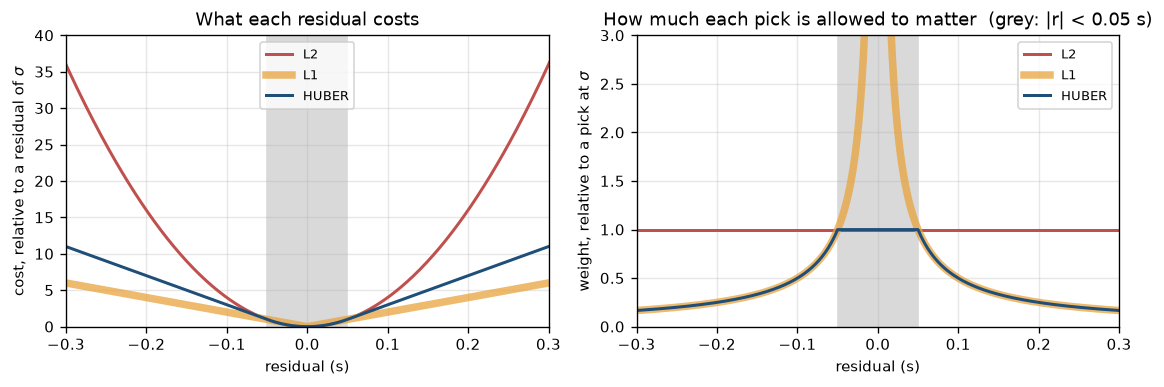

Against a well-read pick at 0.05 s, an outlier at 0.5 s ...

              costs    and is allowed to matter
   L2          100x                      1.00x
   L1           10x                      0.10x
   HUBER        19x                      0.10x

The first column is the whole motivation for this section. Under least squares that one
bad pick costs as much as a hundred good ones, so the hypocentre moves to appease it. L1
charges it ten times a good pick, Huber about twenty -- both finite, and that is the point.

The second column says the same thing as a weight. L2 gives 1.00: it never discounts
anything, ever. L1 and Huber both give 0.10, and the right panel shows why they agree --
outside sigma they are the same function. They differ INSIDE it, where L1 keeps sharpening
without bound as a residual approaches zero and Huber levels off.


In [22]:
r = np.linspace(-0.6, 0.6, 601)
# Huber's one free parameter: the residual at which a pick stops being "normal" and starts being
# an outlier. The rule of thumb is one to two times the reading error, and the sweep at the end
# of A.7 checks it. Our planted picks are read to about 0.03 s, so:
SIGMA = 0.05
# A penalty and an IRLS weight are both defined only up to an overall constant: multiplying
# every pick's cost by the same factor moves nothing. Comparing the raw curves is therefore
# meaningless -- and worse, misleading, because the arbitrary constants differ per loss. So each
# curve is divided by its own value at |r| = sigma. All three then pass through the same point
# and the comparison is about SHAPE, which is the only thing that actually differs.
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.3))
# L1 is drawn as a wide translucent band because outside sigma it and Huber are the SAME
# function: a single-width line would put one exactly on top of the other and one of them would
# simply be invisible. The band makes the agreement, and where it ends, something you can see.
for kind, c, lw, al in (("l2", "#c0504d", 1.8, 1.0), ("l1", "#e8a33d", 4.5, 0.75),
                        ("huber", "#1f4e79", 1.8, 1.0)):
    rho_s = float(gl.rho(np.array([SIGMA]), kind, SIGMA)[0])
    w_s = float(gl.weights(np.array([SIGMA]), kind, SIGMA)[0])
    ax[0].plot(r, gl.rho(r, kind, SIGMA) / rho_s, c=c, lw=lw, alpha=al, label=kind.upper())
    ax[1].plot(r, gl.weights(r, kind, SIGMA) / w_s, c=c, lw=lw, alpha=al, label=kind.upper())
for a in ax:
    a.axvspan(-SIGMA, SIGMA, color="0.85", zorder=0)
    a.set_xlim(-6 * SIGMA, 6 * SIGMA)
ax[0].set(xlabel="residual (s)", ylim=(0, 40),
          ylabel=r"cost, relative to a residual of $\sigma$",
          title="What each residual costs")
ax[1].set(xlabel="residual (s)", ylim=(0, 3.0),
          ylabel=r"weight, relative to a pick at $\sigma$",
          title=f"How much each pick is allowed to matter  (grey: |r| < {SIGMA} s)")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

# Costs and weights are each meaningful only as ratios, so ask each loss about itself: what does
# an outlier ten sigma out cost, and how much is it allowed to matter, next to a good pick at one
# sigma? Those two questions are the left and right panels, as single numbers.
pair = np.array([SIGMA, 10 * SIGMA])
print(f"Against a well-read pick at {SIGMA:.2f} s, an outlier at {10 * SIGMA:.1f} s ...\n")
print(f"   {'':6}{'costs':>10}{'and is allowed to matter':>28}")
for kind in ("l2", "l1", "huber"):
    c = gl.rho(pair, kind, SIGMA)
    w = gl.weights(pair, kind, SIGMA)
    print(f"   {kind.upper():6}{c[1] / c[0]:9.0f}x{w[1] / w[0]:26.2f}x")
print("\nThe first column is the whole motivation for this section. Under least squares that one")
print("bad pick costs as much as a hundred good ones, so the hypocentre moves to appease it. L1")
print("charges it ten times a good pick, Huber about twenty -- both finite, and that is the point.")
print("\nThe second column says the same thing as a weight. L2 gives 1.00: it never discounts")
print("anything, ever. L1 and Huber both give 0.10, and the right panel shows why they agree --")
print("outside sigma they are the same function. They differ INSIDE it, where L1 keeps sharpening")
print("without bound as a residual approaches zero and Huber levels off.")


### The experiment, and one design decision that matters

Plant 250 earthquakes, corrupt about one pick in ten with a gross error — the rate the real data
show — then locate every event four ways and compare with the truth we planted. What is held
fixed is the data, the starting point, the travel-time model and the optimiser. **Only the
function being minimised changes.**

The decision worth spelling out is how the *events* differ from each other, because the obvious
choice is wrong. If every planted earthquake gets the same number of picks and the same reading
error, then every event is equally well recorded, and a robust loss has no population of
badly-recorded events to rescue — it can only help each event by the same modest amount.

Real catalogues are not like that at all. A small earthquake near the edge of the network is
recorded at **fewer** stations, its arrivals are **harder to read**, and **more** of its picks
are wrong — all three at once, because all three follow from the same weak signal. A big
well-placed event is good on all three counts. So we draw one quality per event and let it
drive all three, which is the smallest change that makes the synthetic behave like a catalogue.


In [23]:
BAD = 0.105        # the outlier rate Part B measures on the real 2016 picks; we aim the synthetic at it


def mixed_events(n, st, tabs, seed):
    """A population whose events differ in quality the way a real catalogue's do.

    One number `q` per event, 0 = badly recorded and 1 = well recorded, drives the number of
    stations that picked it, how precisely they were read, and how many of those picks are
    gross errors. Yields the same tuple as `gl.events`, plus `q` itself.
    """
    r = np.random.default_rng(seed)
    for _ in range(n):
        q = r.random()
        truth = np.array([r.uniform(-4, 4), r.uniform(-4, 4),
                          r.uniform(0.5, 3.5), r.uniform(-0.5, 0.5)])
        n_drop = len(st) - (12 + int(round(q * 8)))          # 12 picks at worst, 20 at best
        drop = r.choice(len(st), n_drop, replace=False) if n_drop > 0 else None
        yield (truth,
               *gl.observe(truth, st, tabs,
                           noise=0.020 + 0.025 * (1 - q),          # read less precisely
                           bad=0.03 + 0.260 * (1 - q) ** 2,        # and more often wrong
                           bad_scale=0.35, drop=drop,
                           seed=int(r.integers(1 << 31))),
               q)


pop_full = list(mixed_events(250, st, tabs, seed=11))
cases = [c[:5] for c in pop_full]              # the usual (truth, sta, t_obs, phase, is_bad)
qual = np.array([c[5] for c in pop_full])      # and the quality that produced each one
npk = np.array([len(c[2]) for c in cases])
n_bad = sum(int(c[4].sum()) for c in cases)
print(f"{len(cases)} planted events, {npk.sum():,} picks, "
      f"{n_bad} of them corrupted ({100 * n_bad / npk.sum():.1f} %), against the "
      f"{100 * BAD:.1f} % Part B measures on the real picks\n")
print(f"{'':28}{'worst quarter':>15}{'median':>10}{'best quarter':>14}")
lo, hi = qual < np.percentile(qual, 25), qual > np.percentile(qual, 75)
nz = np.array([0.020 + 0.025 * (1 - q) for q in qual])
br = np.array([c[4].mean() for c in cases])
for lab, v, f in (("picks per event", npk, "{:.0f}"), ("reading error (s)", nz, "{:.3f}"),
                  ("fraction of picks wrong", br, "{:.2f}")):
    print(f"{lab:28}{f.format(np.median(v[lo])):>15}{f.format(np.median(v)):>10}"
          f"{f.format(np.median(v[hi])):>14}")
print("\nThat spread is the point: the worst-recorded quarter of this catalogue is a different")
print("kind of object from the best-recorded quarter, and a method that only moves the median is")
print("not helping where the help is needed.")

res = {}
for label, kw in (("L2 (least squares)", dict(loss="l2")),
                  ("L1", dict(loss="l1")),
                  ("Huber", dict(loss="huber", sigma=SIGMA))):
    e = []
    for truth, s_i, t_i, p_i, _ in cases:
        out = gl.locate(s_i, t_i, p_i, tabs,
                        x0=[s_i[:, 0].mean(), s_i[:, 1].mean(), 2.0, 0.0], **kw)
        e.append(np.linalg.norm(out["m"][:3] - truth[:3]))
    res[label] = np.array(e)


def table(res):
    print(f"{'':22}{'median':>10}{'90th pct':>11}{'> 1 km':>9}")
    for k, v in res.items():
        print(f"{k:22}{1000 * np.median(v):7.0f} m {1000 * np.percentile(v, 90):8.0f} m "
              f"{100 * np.mean(v > 1.0):6.0f} %")


table(res)
b = res["L2 (least squares)"]
print(f"\nagainst L2:  L1 {np.median(b) / np.median(res['L1']):.1f}x better on the median, "
      f"Huber {np.median(b) / np.median(res['Huber']):.1f}x")


250 planted events, 3,936 picks, 401 of them corrupted (10.2 %), against the 10.5 % Part B measures on the real picks

                              worst quarter    median  best quarter
picks per event                          13        16            18
reading error (s)                     0.042     0.033         0.025
fraction of picks wrong                0.23      0.07          0.00

That spread is the point: the worst-recorded quarter of this catalogue is a different
kind of object from the best-recorded quarter, and a method that only moves the median is
not helping where the help is needed.


                          median   90th pct   > 1 km
L2 (least squares)       1364 m     6244 m     58 %
L1                        541 m     2232 m     29 %
Huber                     484 m     2420 m     27 %

against L2:  L1 2.5x better on the median, Huber 2.8x


Two things to take from that table before we add a fourth method.

**Any robust loss beats least squares by a wide margin**, and the gap is in the same place for
both: the fraction of events landing more than a kilometre out collapses.

**L1 and Huber land close to each other, and that is worth noticing rather than glossing.**
They are not really rival theories: outside $\sigma$ they are the same function, and they differ
only in how they treat residuals *smaller* than $\sigma$. Which of them wins on a given data set
is mostly a statement about $\sigma$, not about the losses — and $\sigma$ is a number somebody
chose. We chose ours by a rule of thumb, and the sweep at the end of A.7 checks whether the rule
was any good. **A robust loss has a scale parameter, and it is not a free choice.**


## A.7 · Two more ways to distrust a pick

### RANSAC: an outlier model rather than a heavy tail

L1 and Huber say "all picks come from one population, which has a fat tail". RANSAC says something
different and arguably more honest: **some picks are simply wrong and should not vote at all.**

The procedure is:

1. draw a *minimal* subset of picks — barely enough to locate;
2. locate using only those;
3. count how many of *all* the picks agree with that answer, within a threshold;
4. keep whichever subset won the most agreement, and refit using its whole consensus set.

It works because a subset that happens to contain no bad picks produces a good hypocentre, which
then attracts all the other good picks; a subset containing a bad pick produces a hypocentre that
nothing else agrees with.

**ADLoc's one change**, which we include here: draw the subsets with probability proportional to
the picker's own confidence score, rather than uniformly. A machine picker reports how sure it is,
and that number is free information about which picks are likely to be wrong.


In [24]:
e = []
for truth, s_i, t_i, p_i, _ in cases:
    out = gl.ransac(s_i, t_i, p_i, tabs,
                    x0=[s_i[:, 0].mean(), s_i[:, 1].mean(), 2.0, 0.0],
                    thresh=0.15, trials=40, minimal=6, seed=3)
    e.append(np.linalg.norm(out["m"][:3] - truth[:3]))
res["RANSAC + refit"] = np.array(e)
table(res)
base = res["L2 (least squares)"]
print(f"\nHuber against L2:  median {np.median(base) / np.median(res['Huber']):.1f}x better, "
      f"90th percentile {np.percentile(base, 90) / np.percentile(res['Huber'], 90):.1f}x better")


                          median   90th pct   > 1 km
L2 (least squares)       1364 m     6244 m     58 %
L1                        541 m     2232 m     29 %
Huber                     484 m     2420 m     27 %
RANSAC + refit            435 m     1365 m     20 %

Huber against L2:  median 2.8x better, 90th percentile 2.6x better


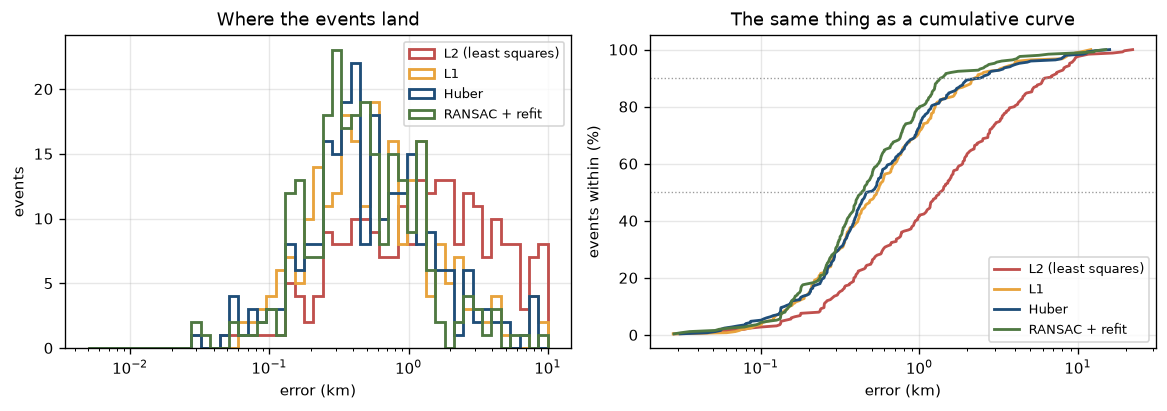

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.5))
bins = np.logspace(-2.3, 1.0, 50)
cols = ("#c0504d", "#e8a33d", "#1f4e79", "#4f7942")
for (k, v), c in zip(res.items(), cols):
    ax[0].hist(np.clip(v, 1e-2, None), bins=bins, histtype="step", lw=1.7, label=k, color=c)
    xs = np.sort(v)
    ax[1].plot(xs, 100 * np.arange(1, len(xs) + 1) / len(xs), c=c, lw=1.7, label=k)
ax[0].set(xscale="log", xlabel="error (km)", ylabel="events", title="Where the events land")
ax[0].legend(fontsize=7.5)
ax[1].set(xscale="log", xlabel="error (km)", ylabel="events within (%)",
          title="The same thing as a cumulative curve")
ax[1].axhline(50, c="0.6", lw=0.8, ls=":"); ax[1].axhline(90, c="0.6", lw=0.8, ls=":")
ax[1].legend(fontsize=7.5, loc="lower right")
fig.tight_layout()
plt.show()


### Using what the picker already told you

Everything so far inferred which picks to distrust *from the residuals*. But the picks usually
arrive with a quality label already attached: an analyst marks an arrival impulsive or emergent,
and a machine picker reports a probability. That is independent information about which data to
believe, available before any inversion, and it enters as a per-datum weight $w_i$ multiplying
each term in the sum.

The label is never perfect. Below, a bad pick usually scores lower than a good one, but the two
distributions overlap substantially — which is exactly the situation in a real catalogue.


In [26]:
r5 = np.random.default_rng(5)
# The label knows two things, as a real one does: whether this particular pick is bad, and how
# clear the record was overall. Both are judged when the arrival is read, before any inversion.
scores = [np.clip(np.where(bad, r5.normal(0.55, 0.25, len(bad)), r5.normal(0.80, 0.15, len(bad)))
                  + 0.15 * (q - 0.5), 0.05, 1.0)
          for (*_, bad), q in zip(cases, qual)]
all_bad = np.concatenate([c[4] for c in cases])
all_sc = np.concatenate(scores)
print(f"declared score: good picks average {all_sc[~all_bad].mean():.2f}, "
      f"bad picks average {all_sc[all_bad].mean():.2f}")
print(f"but {100 * np.mean(all_sc[all_bad] > np.median(all_sc[~all_bad])):.0f} % of the bad picks "
      f"still score above the median good pick — the label is informative, not decisive\n")

e = []
for (truth, s_i, t_i, p_i, _), sc in zip(cases, scores):
    out = gl.locate(s_i, t_i, p_i, tabs, x0=[s_i[:, 0].mean(), s_i[:, 1].mean(), 2.0, 0.0],
                    loss="huber", sigma=SIGMA, pick_w=sc)
    e.append(np.linalg.norm(out["m"][:3] - truth[:3]))
res["Huber + declared weights"] = np.array(e)
table(res)
h, hw = res["Huber"], res["Huber + declared weights"]
print(f"\nweights on top of Huber: {np.median(h) / np.median(hw):.2f}x on the median, "
      f"{np.percentile(h, 90) / np.percentile(hw, 90):.2f}x at the 90th percentile")


declared score: good picks average 0.80, bad picks average 0.52
but 11 % of the bad picks still score above the median good pick — the label is informative, not decisive



                          median   90th pct   > 1 km
L2 (least squares)       1364 m     6244 m     58 %
L1                        541 m     2232 m     29 %
Huber                     484 m     2420 m     27 %
RANSAC + refit            435 m     1365 m     20 %
Huber + declared weights    446 m     1570 m     21 %

weights on top of Huber: 1.08x on the median, 1.54x at the 90th percentile


**The weights barely move the typical event and clearly help the badly recorded ones.** That
asymmetry is the point, and it is the first time in this session we have reproduced it: a typical
event has enough good picks that one more piece of information changes little, while an event
whose solution was being dragged by two bad picks is rescued when those picks are told in advance
to count less.

It also says something about where effort is worth spending. A robust loss discovers bad data
*after* the fact, from the residuals, and can be fooled when the bad data are numerous enough to
out-vote the good. A quality label is independent evidence that does not depend on the solution
at all. Using both is better than either, which is why Part B's ladder ends with exactly this
step, and why its effect there shows up in the 90th percentile rather than the median.


### What this predicts for the real data

Compare the size of this effect with A.4's. There, changing the *optimiser* — from a broken one to
a working one — mattered enormously when the starting point was bad and not at all when it was
good. Here, changing the *objective* moves every part of the distribution by a factor of a few,
and no amount of optimiser cleverness recovers it, because
all four methods above found the true minimum of the function they were given. They simply were
not given the same function.

**With heavy-tailed residuals, the loss decides the answer more than the optimiser does.** That is
the single most transferable sentence in this session, and it is not about seismology: it is the
same reason a mean is a poor summary of house prices.

Look also at *where* each thing helps, because the two robust ideas in this session do not help
in the same place, and the distinction survives into Part B.

**The loss helps everywhere.** Swapping L2 for Huber improves the median and the 90th percentile
by similar factors, because outliers are scattered through the whole population and every event
has some.

**The declared weights help only the tail.** They barely touch the typical earthquake and cut
the 90th percentile substantially. That asymmetry is not an accident of this run — it is the
direct consequence of the design decision two cells ago. A well-recorded event has twenty good
picks, so telling it which two to distrust changes nothing it could not work out for itself. A
badly-recorded event has twelve picks of which a fifth are wrong, its residuals are too few and
too contaminated for the loss to identify the culprits from the fit alone, and an independent
label from outside the inversion is the only new information available.

That is the general lesson, and it is not about seismology: **information that comes from
outside the fit is worth most exactly where the fit itself is weakest.**

### Optional: the catalogue is already doing this

The network's own picks carry a weight code, and the catalogue sets that weight to zero for a
few per cent of them. In Part B we will find that the picks it discards have a median absolute
residual of nearly a second. In other words the analysts, decades before anyone wrote the word
"robust" in this context, were doing by hand what Huber does by formula.


### Optional: robustness from the formulation, not from the loss

Every method so far fought outliers by changing $\rho$ — by deciding how much a large residual
should be allowed to cost. There is a different route, and it is worth seeing because it comes
from A.5 rather than from A.6.

A residual needs an origin time: $r_i = t_i - T_i(\mathbf m) - t_0$. But the *difference* between
two picks does not,

$$ (t_i - t_j) \;-\; \bigl[T_i(\mathbf m) - T_j(\mathbf m)\bigr],$$

because $t_0$ cancels. So we can drop the origin time from the problem entirely and score a
trial location on how well it explains every **pair** of arrivals. That is the
**equal-differential-time** likelihood, the objective NonLinLoc is usually run with (Lomax et al.
2000, [10.1007/978-94-015-9536-0_5](https://doi.org/10.1007/978-94-015-9536-0_5)).

Two things follow, and neither is a choice we make — both are consequences of the form.

**The origin time stops being a nuisance parameter.** A.5's whole difficulty was that $t_0$ is
confounded with depth. Here it is not estimated at all; it is recovered afterwards, once the
location is known.

**It is robust without a robust loss.** Each pair contributes a *bump* — something near 1 when
the pair agrees and near 0 when it does not — instead of a squared penalty that grows without
limit. One bad pick spoils the pairs it belongs to and contributes nothing to them, while the
pairs among the good picks keep voting. Contrast that with least squares, where one bad pick
does not merely fail to help: it actively drags the answer, because making it *less* wrong is
always worth more than keeping the good picks happy.


In [27]:
def edt_misfit(xyz, sta_, t_, ph_, sig=0.05):
    """Equal-differential-time: every PAIR of picks votes, and the origin time never appears."""
    r = np.maximum(np.hypot(xyz[0] - sta_[:, 0], xyz[1] - sta_[:, 1]), 1e-3)
    t = np.empty(len(sta_))
    for q in (0, 1):
        s = ph_ == q
        if s.any():
            t[s] = gl.predict(tabs[q], sta_[s, 2], xyz[2], r[s])[0]
    iu = np.triu_indices(len(t_), 1)
    d = ((t_[:, None] - t_[None, :]) - (t[:, None] - t[None, :]))[iu]
    return -np.sum(np.exp(-(d / sig) ** 2))          # bumps, not squares


def l2_misfit(xyz, sta_, t_, ph_):
    """The ordinary sum of squares, with the best origin time profiled out."""
    r = np.maximum(np.hypot(xyz[0] - sta_[:, 0], xyz[1] - sta_[:, 1]), 1e-3)
    t = np.empty(len(sta_))
    for q in (0, 1):
        s = ph_ == q
        if s.any():
            t[s] = gl.predict(tabs[q], sta_[s, 2], xyz[2], r[s])[0]
    d = t_ - t
    return np.sum((d - d.mean()) ** 2)


def grid_best(fn, sta_, t_, ph_, half=2.5, n=31):
    """Both objectives are searched, not iterated, so the comparison is of the objectives alone."""
    ax = [np.linspace(TRUTH[k] - half, TRUTH[k] + half, n) for k in (0, 1)]
    az = np.linspace(0.3, 4.5, n)
    best = (np.inf, None)
    for x in ax[0]:
        for y in ax[1]:
            for z in az:
                v = fn((x, y, z), sta_, t_, ph_)
                if v < best[0]:
                    best = (v, (x, y, z))
    return np.array(best[1])


s_e, t_e, p_e, _ = gl.observe(TRUTH, st, tabs, noise=0.03, seed=1)
print(f"{'':24}{'least squares':>16}{'EDT':>10}   (distance from the planted truth)")
for lab, spoil in (("clean picks", ()), ("two picks 1.5 s out", (3, 11))):
    tt = t_e.copy()
    for k, sgn in zip(spoil, (+1, -1)):
        tt[k] += sgn * 1.5
    out = []
    for fn in (lambda *a: l2_misfit(*a), edt_misfit):
        m = grid_best(fn, s_e, tt, p_e)
        out.append(1000 * np.linalg.norm(m - TRUTH[:3]))
    print(f"{lab:24}{out[0]:13.0f} m{out[1]:9.0f} m")
print("\nOn clean picks the two agree, and both sit at the resolution of the grid we searched.")
print("Two gross outliers move least squares kilometres and barely touch EDT -- and note that no")
print("robust loss was used here at all. The robustness is in the shape of the objective.")


                           least squares       EDT   (distance from the planted truth)


clean picks                       120 m      120 m


two picks 1.5 s out              3375 m      260 m

On clean picks the two agree, and both sit at the resolution of the grid we searched.
Two gross outliers move least squares kilometres and barely touch EDT -- and note that no
robust loss was used here at all. The robustness is in the shape of the objective.


### How much does the Huber scale matter?

`sigma` is where Huber decides that "a normal pick" has become "an outlier", and we set it by a
rule of thumb rather than by evidence. Because we planted the truth, we can check the rule
instead of trusting it: sweep `sigma` over two orders of magnitude and look.


In [28]:
sweep = {}
for s in (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 2.0):
    e = [np.linalg.norm(gl.locate(s_i, t_i, p_i, tabs,
                                  x0=[s_i[:, 0].mean(), s_i[:, 1].mean(), 2.0, 0.0],
                                  loss="huber", sigma=s)["m"][:3] - truth[:3])
         for truth, s_i, t_i, p_i, _ in cases]
    sweep[s] = float(np.median(e))
# Naming a single winner would be reading noise -- several of these sit within a few metres of
# each other. What the sweep actually shows is the SHAPE, so print each value against the best.
lo = min(sweep.values())
print(f"  {'sigma':>7}{'median error':>15}{'vs the best':>14}")
for s, v in sweep.items():
    print(f"  {s:6.2f} s{1000 * v:13.0f} m{v / lo:12.2f}x")
print(f"\nThere is no peak to find here. Every sigma at or below the typical reading error lands")
print(f"within a few per cent of the best, and above it the error climbs steadily -- "
      f"{max(sweep.values()) / lo:.1f}x by sigma = {max(sweep):.1f} s.")
# A cheap self-check: this sweep at our own sigma must reproduce the Huber row of the table
# above, because it is the same computation. If these two ever disagree, one of them is stale.
print(f"\n(check: sigma = {SIGMA} here gives {1000 * sweep[SIGMA]:.0f} m, and the Huber row above "
      f"gives {1000 * np.median(res['Huber']):.0f} m -- the same run)")
print(f"large sigma tends to L2 ({1000 * np.median(res['L2 (least squares)']):.0f} m); "
      f"small sigma tends to L1 ({1000 * np.median(res['L1']):.0f} m)")


    sigma   median error   vs the best
    0.01 s          490 m        1.07x
    0.02 s          460 m        1.00x
    0.05 s          484 m        1.05x
    0.10 s          565 m        1.23x
    0.20 s          774 m        1.68x
    0.50 s         1112 m        2.42x
    2.00 s         1364 m        2.96x

There is no peak to find here. Every sigma at or below the typical reading error lands
within a few per cent of the best, and above it the error climbs steadily -- 3.0x by sigma = 2.0 s.

(check: sigma = 0.05 here gives 484 m, and the Huber row above gives 484 m -- the same run)
large sigma tends to L2 (1364 m); small sigma tends to L1 (541 m)


Both limits are visible, and they are the two losses we already met. A very large `sigma` never
leaves the quadratic, so Huber *becomes* L2 and inherits its median. A very small one is linear
almost everywhere, so it becomes L1. Huber is not a third loss so much as a dial between the
two, and `sigma` is the dial.

What lies between them is the useful part, and it is **not** a peak to be found. The curve is
flat all the way up from the smallest $\sigma$ we tried to roughly the reading error, and only
then does it climb. So the rule of thumb is better stated as a **ceiling than a target**: too
small costs you almost nothing here, too large costs you a great deal, and the penalty is
entirely one-sided.

That asymmetry is what makes the rule usable on real data, where this sweep cannot be run —
erring downwards is nearly free. Part B sweeps $\sigma$ on the real picks and finds the same
one-sided shape, which is the reassurance that this is a property of the loss rather than of
our synthetic.

This is a hyperparameter in exactly week 1's sense, and the contrast with week 1 is the point.
There we chose ridge's $\lambda$ by cross-validation, which needs no truth — only held-out data.
Here the quantity we want to be good at is *distance from the true hypocentre*, and no amount of
held-out arrival-time data reveals it. A planted world is the only place this curve can be
drawn, which is why we drew it here and take the rule of thumb to the real picks in Part B.


## A.8 · Three error bars, and why they are not three estimates of one number

Week 1 got its error bar from the curvature of the likelihood at the optimum. That works here
too, and it is what every location code prints. But the non-linearity gives us two other routes,
and the three answer **different questions**:

| | what it asks | what it assumes |
|---|---|---|
| **formal ellipse** $\;\sigma^2(\mathbf{G}^{\mathsf T}\mathbf{G})^{-1}$ | how sharply does the misfit curve at the minimum? | the misfit is a paraboloid; every pick has the same Gaussian error |
| **bootstrap** | what if the network had recorded a different set of picks? | the picks I have are representative |
| **grid posterior** | what does the likelihood actually look like, everywhere? | nothing about shape — it just evaluates |

The third is not a teaching device: evaluating the likelihood over a grid and keeping the whole
distribution, rather than a point and a covariance, is what **NonLinLoc** does in production
(Lomax et al. 2000), and A.7's equal-differential-time objective is the likelihood it usually
evaluates. A.12 returns to the cost of doing it this way, and to what replaces it.

One trap first, and it is easy to fall into: these can only be compared if they are given the
**same** $\sigma$. The formal ellipse estimates $\sigma$ from the residuals; if you hand the grid
the true noise instead, the two differ by a constant factor and you will conclude something about
curvature that is really about bookkeeping.


In [29]:
sta, t_obs, phase, _ = gl.observe(TRUTH, st, tabs, noise=NOISE, seed=3)
out = gl.locate(sta, t_obs, phase, tabs, x0=[0.0, 0.0, 5.0, 0.0])
shat = float(np.sqrt(np.sum(out["res"] ** 2) / (out["n"] - 4)))
print(f"located {1000 * np.linalg.norm(out['m'][:3] - TRUTH[:3]):.0f} m from the truth, "
      f"using {out['n']} picks")
print(f"the noise we put in was {NOISE:.3f} s; sigma estimated from the residuals is {shat:.4f} s")

C = gl.ellipse(out)
formal = np.sqrt(np.diag(C))[:3]

B = gl.bootstrap(sta, t_obs, phase, tabs, out["m"], n=300, seed=5)
boot = B[:, :3].std(axis=0)

P = gl.posterior(sta, t_obs, phase, tabs, out["m"], half=0.9, step=0.03, sigma=shat)
p3 = P["p"]
marg = (p3.sum(axis=(0, 1)), p3.sum(axis=(0, 2)), p3.sum(axis=(1, 2)))     # x, y, z
grid = np.array([np.sqrt(np.sum(g ** 2 * m) - np.sum(g * m) ** 2)
                 for g, m in zip((P["x"], P["y"], P["z"]), marg)])

print(f"\n{'':22}{'x':>9}{'y':>9}{'z':>9}   (standard deviation, km)")
for label, s in (("formal ellipse", formal), ("grid posterior", grid), ("bootstrap", boot)):
    print(f"{label:22}{s[0]:9.4f}{s[1]:9.4f}{s[2]:9.4f}")
print(f"\n{'grid / formal':22}{grid[0] / formal[0]:9.2f}{grid[1] / formal[1]:9.2f}{grid[2] / formal[2]:9.2f}")
print(f"{'bootstrap / formal':22}{boot[0] / formal[0]:9.2f}{boot[1] / formal[1]:9.2f}{boot[2] / formal[2]:9.2f}")


located 116 m from the truth, using 20 picks
the noise we put in was 0.030 s; sigma estimated from the residuals is 0.0395 s



                              x        y        z   (standard deviation, km)
formal ellipse           0.0971   0.0864   0.2385
grid posterior           0.0982   0.0879   0.2444
bootstrap                0.1143   0.0561   0.2665

grid / formal              1.01     1.02     1.02
bootstrap / formal         1.18     0.65     1.12


**Read that table carefully, because it does not say what the textbook picture would suggest.**

The grid posterior and the formal ellipse agree closely **in width** — to a couple of per cent
in every direction. For this problem, at this station geometry, the log-likelihood really is
close to a paraboloid, so the ellipse is not a crude approximation of a wildly curved posterior.

But look at the depth marginal in the figure below rather than only at the number. The two
curves have the same standard deviation and visibly different **tails**: the true posterior
carries more probability far from the peak than the Gaussian does. A standard deviation is
insensitive to that; a 95 % region is made of almost nothing else. Keep it in mind for A.9,
where we count how often the truth actually falls inside.

The **bootstrap** is the one that disagrees, and notice *how*: not by a constant factor, but
differently along different axes. That is the signature of something the other two cannot see.
The formal ellipse treats every pick as an interchangeable draw with a common $\sigma$; the
bootstrap discovers that the answer depends on *which* stations you happened to get. A handful
of near stations carry most of the information about depth, so resampling matters a lot in the
directions those stations control and little in the others. Run it with a different seed and
these ratios will move — with a few hundred resamples they are themselves uncertain, which is
worth remembering before reading much into any single one.

Below, the exact posterior is drawn with the ellipse over it.


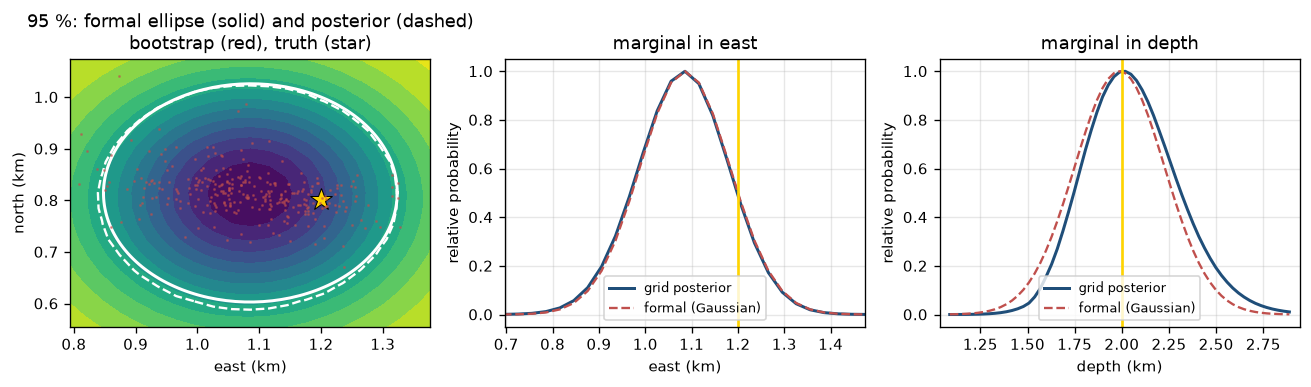

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.3))
pxy = p3.sum(axis=0)                       # (y, x) after summing over depth

# The posterior falls off so fast that a linear colour scale shows one bright dot on a flat
# field. Stretching it (a power < 1) lets the skirts of the distribution be seen, which is where
# the comparison with the ellipse actually lives.
ax[0].contourf(P["x"], P["y"], (pxy / pxy.max()) ** 0.3, np.linspace(0, 1, 15), cmap="viridis_r")

# The grid posterior's own 95 % region: the smallest set of nodes holding 95 % of the probability.
pn = pxy / pxy.sum()
srt = np.sort(pn.ravel())[::-1]
lev95 = srt[min(int(np.searchsorted(np.cumsum(srt), 0.95)), len(srt) - 1)]
ax[0].contour(P["x"], P["y"], pn, [lev95], colors="w", linewidths=1.4, linestyles="--")

th = np.linspace(0, 2 * np.pi, 200)
L = np.linalg.cholesky(np.asarray(C)[:2, :2] * 5.991)          # chi-square 95 %, 2 dof
e = (L @ np.vstack([np.cos(th), np.sin(th)])) + out["m"][:2, None]
ax[0].plot(e[0], e[1], "w-", lw=1.8)
ax[0].plot(*TRUTH[:2], "*", ms=14, mfc="#ffd400", mec="k", mew=0.6)
ax[0].plot(B[:, 0], B[:, 1], ".", ms=1.6, c="#c0504d", alpha=0.5)
ax[0].set(xlabel="east (km)", ylabel="north (km)",
          xlim=(out["m"][0] - 3 * formal[0], out["m"][0] + 3 * formal[0]),
          ylim=(out["m"][1] - 3 * formal[1], out["m"][1] + 3 * formal[1]),
          title="95 %: formal ellipse (solid) and posterior (dashed)\n"
                "bootstrap (red), truth (star)")

for a, g, m, lab in ((ax[1], P["x"], marg[0], "east (km)"), (ax[2], P["z"], marg[2], "depth (km)")):
    a.plot(g, m / m.max(), c="#1f4e79", lw=1.8, label="grid posterior")
    mu = out["m"][0 if lab.startswith("east") else 2]
    sd = formal[0 if lab.startswith("east") else 2]
    a.plot(g, np.exp(-0.5 * ((g - mu) / sd) ** 2), c="#c0504d", lw=1.4, ls="--",
           label="formal (Gaussian)")
    a.axvline(TRUTH[0 if lab.startswith("east") else 2], c="#ffd400", lw=1.6)
    a.set(xlabel=lab, ylabel="relative probability", title=f"marginal in {lab.split()[0]}",
          xlim=(mu - 4 * sd, mu + 4 * sd))      # the grid is wider than the answer; crop to it
    a.legend(fontsize=7.5)
fig.tight_layout()
plt.show()


## A.9 · The coverage test — does the error bar contain the truth?

This is the section the whole synthetic apparatus exists for.

An error bar is a **claim about repeated experiments** — week 1's definition. A 95 % region claims
that if you did this many times, the truth would be inside it 95 % of the time. That is a
falsifiable statement, and in a planted world we can simply check it: locate many events, draw
each 95 % region, and count.

We run it twice. Once with the **right** velocity model, where the only error is the reading
noise we put in. And once locating with **GIL7** — the northern California model, a perfectly
respectable model that is simply not the model of this field. Nothing else changes: same
earthquakes, same picks, same noise, same algorithm, same loss.


In [31]:
def coverage(cases, tabs_fit, dof=3):
    hit, err = [], []
    for truth, sta, t_obs, phase, _ in cases:
        o = gl.locate(sta, t_obs, phase, tabs_fit,
                      x0=[sta[:, 0].mean(), sta[:, 1].mean(), 2.0, 0.0])
        Cv = np.asarray(gl.ellipse(o))[:dof, :dof]
        d = o["m"][:dof] - np.asarray(truth)[:dof]
        hit.append(gl.inside(Cv, d, dof)[0])
        err.append(o["m"][:3] - np.asarray(truth)[:3])
    return np.mean(hit), np.array(err)


cases = list(gl.events(300, st, tabs, noise=NOISE, seed=7))
cov_r, err_r = coverage(cases, tabs)
cov_w, err_w = coverage(cases, tabs_gil7)

print(f"{'':28}{'coverage of the':>17}{'bias (km)':>26}{'scatter (km)':>24}")
print(f"{'':28}{'95 % region':>17}{'x        y        z':>28}{'x        y        z':>26}")
for lab, cov, e in (("located with the RIGHT model", cov_r, err_r),
                    ("located with the WRONG model", cov_w, err_w)):
    b, s = e.mean(axis=0), e.std(axis=0)
    print(f"{lab:28}{100 * cov:14.1f} %  {b[0]:+8.3f} {b[1]:+8.3f} {b[2]:+8.3f}   "
          f"{s[0]:8.3f} {s[1]:8.3f} {s[2]:8.3f}")


                              coverage of the                 bias (km)            scatter (km)
                                  95 % region         x        y        z       x        y        z
located with the RIGHT model          91.3 %    -0.024   -0.024   +0.038      0.219    0.196    0.270
located with the WRONG model           2.3 %    +0.261   +0.006   +0.963      0.198    0.183    0.381


**The wrong model destroys the error bar.** The 95 % region, computed exactly as every location
program computes it, contains the truth a few per cent of the time.

And look at *how* it fails. The scatter — the random part, which is what the formal ellipse
actually describes — barely changes. What appears is a **bias**, almost all of it in depth: every
event is pushed the same way by the same amount, because the model is wrong in the same way for
all of them. A covariance matrix computed from the fit has no way of knowing this. It measures
how much the answer wobbles, not how far the whole cloud has been displaced.

That is the distinction between **precision** and **accuracy**, and it is why the two words must
be kept apart for the rest of the course:

- **precision** — how tightly repeated measurements agree. The ellipse, the bootstrap and the
  posterior all estimate this, and here they are all roughly right.
- **accuracy** — how close you are to the truth. Nothing in the data can tell you this, because
  the bias is invisible to the residuals.


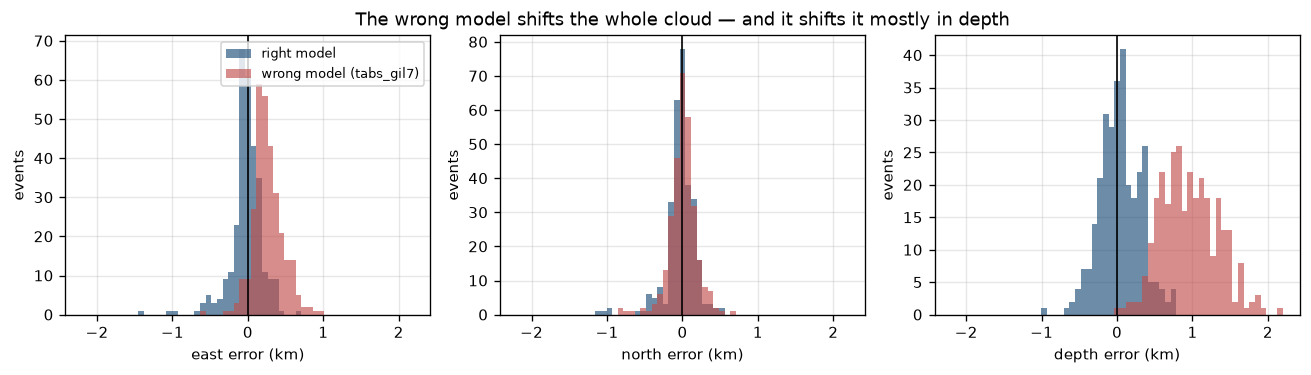

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(11.0, 3.2))
for a, k, lab in ((ax[0], 0, "east error (km)"), (ax[1], 1, "north error (km)"),
                  (ax[2], 2, "depth error (km)")):
    bins = np.linspace(-2.2, 2.2, 60)
    a.hist(err_r[:, k], bins=bins, color="#1f4e79", alpha=0.65, label="right model")
    a.hist(err_w[:, k], bins=bins, color="#c0504d", alpha=0.65, label="wrong model (tabs_gil7)")
    a.axvline(0, c="k", lw=1.0)
    a.set(xlabel=lab, ylabel="events")
    if k == 0:
        a.legend(fontsize=7.5)
ax[1].set_title("The wrong model shifts the whole cloud — and it shifts it mostly in depth")
fig.tight_layout()
plt.show()


### Is the wrong model really invisible? Only if you have P picks alone

"Nothing in the data reveals the bias" is true of the experiment above, and it is *not* true in
general. The experiment used **P picks only**. Add S arrivals and the wrong model stops hiding.

It is worth being clear about where that asymmetry comes from, because it is not in the code:
`layers` reads column 1 of a model for P and column 2 for S, and everything after that — the
table, the Jacobian, the loss, the optimiser — never asks which phase a pick is. **P and S are
treated identically.** The asymmetry is in the models themselves, and there are two separate
mechanisms, which the cell below separates by measurement rather than assertion.

1. **The two models disagree about $V_P/V_S$.** The Geysers model is built as $V_P$ divided by a
   single constant, so its ratio is the same in every layer. GIL7 carries independent S
   velocities and its ratio varies layer by layer, and is most different from the Geysers value
   in the top kilometre — exactly where these shallow rays spend most of their path. A wrong
   ratio cannot be absorbed by moving the earthquake or shifting the origin time, because it
   changes the P and the S prediction at the *same* station by different amounts.
2. **Even with the ratio right, a velocity error costs more in S than in P.** An S wave takes
   about 1.78 times as long to arrive, so the same *fractional* velocity error produces about
   1.78 times the *absolute* timing error — and one origin time cannot absorb two different
   shifts.

To separate them we need a third and a fourth model: GIL7 with its $V_P/V_S$ forced to the
Geysers value, which switches mechanism 1 off, and the right model made uniformly 5 % too fast,
which leaves only mechanism 2.


In [33]:
gil7_same_ratio = gl.GIL7.copy()
gil7_same_ratio[:, 2] = gil7_same_ratio[:, 1] / gl.VPVS       # mechanism 1 switched off
scaled = gl.GEY.copy()
scaled[:, 1:] *= 1.05                                          # only mechanism 2 left
TABS_SAME = [gl.build(gil7_same_ratio, ph, ZR, ZS, RR) for ph in ("P", "S")]
TABS3 = [gl.build(scaled, ph, ZR, ZS, RR) for ph in ("P", "S")]

print("Vp/Vs, layer by layer")
print(f"  the Geysers model {np.round(gl.GEY[:, 1] / gl.GEY[:, 2], 2)}")
print(f"  GIL7              {np.round(gl.GIL7[:, 1] / gl.GIL7[:, 2], 2)}\n")

cases_s = list(gl.events(300, st, tabs, noise=NOISE, s_frac=1.0, seed=7))


def fit_quality(case_list, tabs_fit):
    """Median rms of the fit, and median distance from the planted truth."""
    rms, err = [], []
    for truth, sta_, t_, ph_, _ in case_list:
        o = gl.locate(sta_, t_, ph_, tabs_fit,
                      x0=[sta_[:, 0].mean(), sta_[:, 1].mean(), 2.0, 0.0])
        rms.append(o["rms"])
        err.append(np.linalg.norm(o["m"][:3] - np.asarray(truth)[:3]))
    return float(np.median(rms)), 1000 * float(np.median(err))


print(f"{'located with':34}{'P only':>18}{'P and S':>18}")
print(f"{'':34}{'rms      error':>18}{'rms      error':>18}")
for lab, tf in (("the right model", tabs),
                ("GIL7, its own Vp/Vs", tabs_gil7),
                ("GIL7, Vp/Vs forced to 1.78", TABS_SAME),
                ("the right model, 5 % too fast", TABS3)):
    rp, ep = fit_quality(cases, tf)
    rs, es = fit_quality(cases_s, tf)
    print(f"{lab:34}{rp:8.4f}s{ep:8.0f}m{rs:9.4f}s{es:8.0f}m")
print("\nRead the rms columns. With P alone every wrong model fits nearly as well as the right one,")
print("so the residuals raise no alarm -- that is the blindness the coverage test just exposed.")
print("With S added the alarm sounds, and the two mechanisms are visibly different sizes: forcing")
print("GIL7's Vp/Vs to the Geysers value removes most of the penalty, so the ratio error is the")
print("larger half, and the 5 %-too-fast model shows the smaller half surviving on its own.")


Vp/Vs, layer by layer
  the Geysers model [1.78 1.78 1.78 1.78 1.78 1.78 1.78]
  GIL7              [2.13 1.88 1.73 1.73 1.83 1.83 1.73 1.73]

located with                                  P only           P and S
                                      rms      error    rms      error


the right model                     0.0263s     275m   0.0282s      85m


GIL7, its own Vp/Vs                 0.0314s    1002m   0.1921s    1734m


GIL7, Vp/Vs forced to 1.78          0.0314s    1002m   0.0794s     983m


the right model, 5 % too fast       0.0270s     414m   0.0323s     312m

Read the rms columns. With P alone every wrong model fits nearly as well as the right one,
so the residuals raise no alarm -- that is the blindness the coverage test just exposed.
With S added the alarm sounds, and the two mechanisms are visibly different sizes: forcing
GIL7's Vp/Vs to the Geysers value removes most of the penalty, so the ratio error is the
larger half, and the 5 %-too-fast model shows the smaller half surviving on its own.


**S picks are not a free lunch, and the error columns say so.** With the right model, adding S
improves the location several-fold — that is A.5's second cure working as advertised. With GIL7,
adding S makes the location *worse*, because the solver now believes a $V_P/V_S$ that is wrong
and bends the answer to satisfy it.

So the honest rule is a conditional one: **an S pick is worth a great deal when you trust the
model, and it is a liability when you do not** — and the rms tells you which situation you are
in. That check costs nothing, needs no known truth, and is the single most useful thing you can
do to a velocity model somebody handed you. It is also why a field with few S picks, like the
2016 Geysers, is a field where a wrong velocity model can go unnoticed for a long time.


### Even the right model does not reach 95 %

The right-hand column above is not 95 %, and it is worth being honest about that rather than
quietly rounding. We checked the obvious explanations and none of them accounts for it: using
the true $\sigma$ instead of the estimated one, refining the travel-time table fourfold, starting
the iteration from the grid search, and replacing the formal covariance with the bootstrap
covariance all leave it within a point or two. Some of the shortfall is the $F$ rather than
$\chi^2$ quantile that an *estimated* $\sigma$ strictly calls for — the same correction that made
week 1 use $t$ instead of the normal — and the rest is the residual non-linearity of the problem.

The honest summary is the one to carry: **a formal 95 % region is optimistic even in the best
case, and worthless when the velocity model is wrong.** The size of those two effects is very
different, and only one of them can be fixed by collecting more data.

### What this predicts for the real data

In Part B there is no truth, so coverage cannot be measured. What *can* be measured is the same
bias, by changing the velocity model and watching the whole catalogue move — and it does, mostly
in depth, exactly as here. That correspondence is the reason Part A was worth building.


### How wrong does a model have to be before its error bars stop meaning anything?

GIL7 is a *very* wrong model for this field, so collapsing to a few per cent is not surprising.
The more useful question is how the failure sets in. Take the right model and make every
velocity 5 % too fast — an error small enough that nobody looking at the model would object —
and run the same count.


In [34]:
cov3, err3 = coverage(cases, TABS3)          # the 5 %-too-fast model built two cells above
print(f"velocities 5 % too fast: coverage {100 * cov3:.1f} %, "
      f"depth bias {err3[:, 2].mean():+.3f} km")


velocities 5 % too fast: coverage 70.7 %, depth bias -0.332 km


## A.10 · A 3-D Earth, located with a 1-D model

A.9 used a *different 1-D model* as its wrong model. That is a real mistake people make, but not
the usual one. The usual one is unavoidable: **the Earth is three-dimensional and we located with
a stack of flat layers.** Every routine catalogue in the world carries this error, including the
one Part B reproduces.

It is worth planting properly rather than faking, and there is a cheap, honest way. Put a smooth
three-dimensional velocity anomaly into the ground and integrate the slowness perturbation along
each ray:

$$ \delta t \;=\; \int_{\text{ray}} \delta u \; ds .$$

That is first-order perturbation theory — the same linearisation tomography uses in session 5 —
and it needs no 3-D ray tracer, because to first order the *path* need not be corrected, only the
time along it.

We plant two kinds of structure, because they behave completely differently:

- **shallow anomalies directly beneath each station**, from the weathered rock and topography a
  1-D model cannot express. Every ray arriving at that station passes through them.
- **deeper, broader anomalies through the source volume**, which different earthquakes sample
  differently depending on where they are.


In [35]:
S = st[["x", "y", "z"]].to_numpy()
r_f = np.random.default_rng(11)
N_DEEP = 16
centre = np.vstack([
    S + np.column_stack([r_f.normal(0, .15, len(S)), r_f.normal(0, .15, len(S)),
                         .35 * np.ones(len(S))]),                      # under each station
    np.column_stack([r_f.uniform(-8, 8, N_DEEP), r_f.uniform(-8, 8, N_DEEP),
                     r_f.uniform(0.5, 5.0, N_DEEP)])])                 # through the volume
width = np.concatenate([np.full(len(S), .45), r_f.uniform(2.5, 5.0, N_DEEP)])
amp = np.concatenate([r_f.normal(0, .16, len(S)), r_f.normal(0, .09, N_DEEP)])


N_SHALLOW = len(S)


def dslow(P, which="all"):
    """Slowness perturbation (s/km) at points P, from a sum of smooth Gaussian anomalies.

    `which` selects the shallow station-centred anomalies, the deep ones, or both.
    """
    sl = {"all": slice(None), "shallow": slice(0, N_SHALLOW), "deep": slice(N_SHALLOW, None)}[which]
    d = 0.0
    for c, w, a in zip(centre[sl], width[sl], amp[sl]):
        d = d + a * np.exp(-np.sum((P - c) ** 2, axis=1) / (2 * w * w))
    return d / 5.0                    # a fractional velocity anomaly, divided by a velocity


def dt_ray(src, sta, m=40):
    """The extra travel time the 3-D structure adds, integrated along the straight ray."""
    u = np.linspace(0, 1, m)[:, None]
    return np.trapezoid(dslow(src[None, :] * (1 - u) + sta[None, :] * u),
                        dx=np.linalg.norm(sta - src) / (m - 1))


N_EV, NOISE = 70, 0.03
rng2 = np.random.default_rng(4)
truths = np.column_stack([rng2.uniform(-2.5, 3.5, N_EV), rng2.uniform(-2.0, 3.0, N_EV),
                          rng2.uniform(1.0, 3.0, N_EV), rng2.uniform(-0.3, 0.3, N_EV)])
DT = np.zeros((N_EV, len(S)))
obs, clean = [], []
for i, tr in enumerate(truths):
    s, tc, p, _ = gl.observe(tr, st, tabs, noise=0.0, seed=1)
    DT[i] = [dt_ray(tr[:3], S[k]) for k in range(len(S))]
    clean.append(tc + DT[i])                       # noise-free, used only for the xcorr test
    obs.append((s, tc + DT[i] + rng2.normal(0, NOISE, len(tc)), p))
print(f"{N_EV} earthquakes, {len(S)} stations, {N_DEEP + len(S)} planted anomalies")
print(f"the 3-D structure shifts arrival times by {DT.min():+.3f} to {DT.max():+.3f} s, "
      f"against a reading error of {NOISE} s -- so the model error dominates, as it does in reality")
_g = np.linspace(-5, 5, 40)
_X, _Y = np.meshgrid(_g, _g)
_pk = max(np.abs(dslow(np.column_stack([_X.ravel(), _Y.ravel(), np.full(_X.size, z)])) * 5 * 100).max()
          for z in (0.3, 1.0, 2.0, 3.0, 4.0))
print(f"the strongest anomaly the rays actually cross is {_pk:.0f} % in velocity, which is large "
      f"but not unreasonable\nfor a vapour-dominated geothermal reservoir")


70 earthquakes, 20 stations, 36 planted anomalies
the 3-D structure shifts arrival times by -0.024 to +0.217 s, against a reading error of 0.03 s -- so the model error dominates, as it does in reality
the strongest anomaly the rays actually cross is 20 % in velocity, which is large but not unreasonable
for a vapour-dominated geothermal reservoir


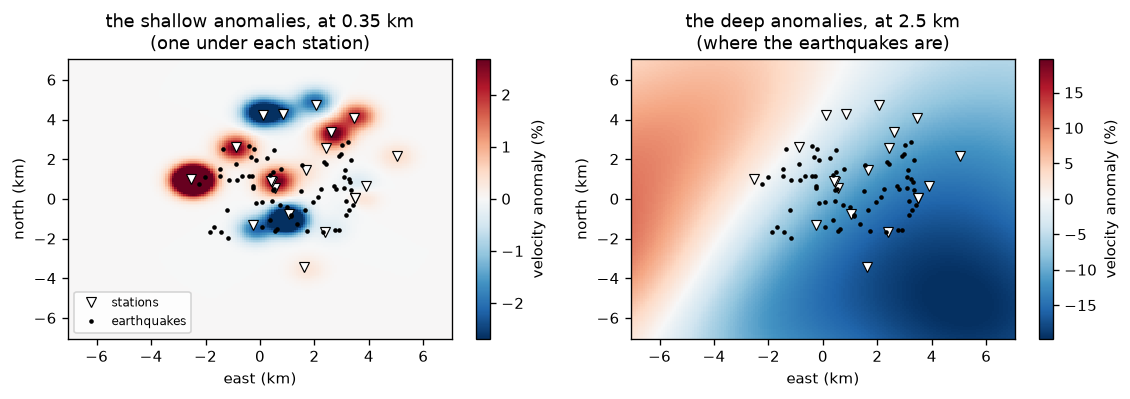

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.4))
gx = np.linspace(-7, 7, 170)
X, Y = np.meshgrid(gx, gx)
for a, which, z, lab in (
        (ax[0], "shallow", 0.35, "the shallow anomalies, at 0.35 km\n(one under each station)"),
        (ax[1], "deep", 2.5, "the deep anomalies, at 2.5 km\n(where the earthquakes are)")):
    P = np.column_stack([X.ravel(), Y.ravel(), np.full(X.size, z)])
    V = (-dslow(P, which) * 5.0 * 100).reshape(X.shape)   # back to a percentage velocity anomaly
    # Scale to the 98th percentile, not the single strongest point: one strong blob otherwise
    # sets the limits and every other anomaly renders as white.
    lim = float(np.percentile(np.abs(V), 98))
    m = a.pcolormesh(gx, gx, V, cmap="RdBu_r", vmin=-lim, vmax=lim, shading="auto")
    a.plot(S[:, 0], S[:, 1], "v", ms=6, mfc="w", mec="k", mew=0.7, label="stations")
    a.plot(truths[:, 0], truths[:, 1], ".", ms=3.5, c="k", label="earthquakes")
    a.set(xlabel="east (km)", ylabel="north (km)", title=lab)
    fig.colorbar(m, ax=a, label="velocity anomaly (%)")
ax[0].legend(fontsize=7, loc="lower left")
fig.tight_layout()
plt.show()


**The two panels look completely different, and that difference is the section in one picture.**

The shallow field is a patchwork: a separate blob under each station, none of them wider than
the spacing between stations. Every ray into a given station crosses that station's blob and no
other, so its effect is the *same constant* for every earthquake — which is precisely what a
station term is.

The deep field, at the depth where the earthquakes actually sit, is dominated instead by one
broad gradient across the field. That is not an accident of the random draw; it is what a sum of
anomalies wider than the network looks like, and real fields behave the same way, because
long-wavelength structure is the part a 1-D model misses most. A smooth gradient is *also*
largely absorbed by a station term — a station in the slow half is late for every event. What
survives both is the short-wavelength part, and the difference between two neighbouring
earthquakes is the only measurement that sees it.

The next cell turns that qualitative argument into numbers, in advance.


### What the error is made of, before we try to remove any of it

This is the most useful cell in the section, because it says **in advance what each method can
possibly achieve.** Split the planted delay into the part that is fixed at each station and the
part left over, then ask how much of the remainder survives differencing two neighbours.


In [37]:
station_fixed = DT.mean(axis=0)
left_over = DT - station_fixed
D_true = np.linalg.norm(truths[:, None, :3] - truths[None, :, :3], axis=2)
np.fill_diagonal(D_true, np.inf)
near = [(i, int(np.argmin(D_true[i]))) for i in range(N_EV)]
after_dd = np.array([left_over[i] - left_over[j] for i, j in near])

print(f"  the whole 3-D delay                     sd {DT.std():.4f} s")
print(f"  its station-fixed part                  sd {station_fixed.std():.4f} s"
      f"  ({100 * station_fixed.var() / DT.var():.0f} % of the variance)")
print(f"  what a static station term cannot reach sd {left_over.std():.4f} s")
print(f"  ... and after differencing near pairs   sd {after_dd.std():.4f} s"
      f"  (median separation {np.median([D_true[i, j] for i, j in near]):.2f} km)")
print("\nA static station term can remove most of it; differencing neighbouring events removes")
print("most of what is left. That is the prediction — the rest of this section tests it.")


  the whole 3-D delay                     sd 0.0473 s
  its station-fixed part                  sd 0.0390 s  (68 % of the variance)
  what a static station term cannot reach sd 0.0267 s
  ... and after differencing near pairs   sd 0.0084 s  (median separation 0.57 km)

A static station term can remove most of it; differencing neighbouring events removes
most of what is left. That is the prediction — the rest of this section tests it.


### The three repairs

**Static station terms.** One constant per station: the average of what is left over there.

**SSST**, source-specific station terms (Richards-Dinger & Shearer 2000,
[10.1029/2000JB900014](https://doi.org/10.1029/2000JB900014)). The same average, taken over only
the events *near* the one being relocated, so a station's term may vary with where the earthquake
was. Lin & Shearer (2005, [10.1029/2004JB003380](https://doi.org/10.1029/2004JB003380)) shrink
that neighbourhood pass by pass, which is what the loop below does: 30 neighbours, then 15, then 8.

**Double difference** (Waldhauser & Ellsworth 2000). Subtract one event's arrival from its
neighbour's, pair by pair, and solve for where the events sit relative to each other.


In [38]:
def locate_all(terms=None, per_event=None):
    return np.array([gl.locate(s, t, p, tabs, x0=[s[:, 0].mean(), s[:, 1].mean(), 2.0, 0.0],
                               terms=(per_event[i] if per_event is not None else terms))["m"]
                     for i, (s, t, p) in enumerate(obs)])


def residual_matrix(M, terms):
    return np.array([gl.residuals(s, t, p, tabs, M[i], terms=terms[i])
                     for i, (s, t, p) in enumerate(obs)])


M_none = locate_all()

static = np.zeros(len(S))                       # average over ALL events
for _ in range(12):
    M = locate_all(static)
    upd = np.median(residual_matrix(M, np.tile(static, (N_EV, 1))), axis=0)
    static = static + upd - upd.mean()          # a common shift is origin time, not a term
M_static = locate_all(static)

terms = np.tile(static, (N_EV, 1))              # SSST: average over the K nearest events
for K in (30, 15, 8):
    M = locate_all(per_event=terms)
    R = residual_matrix(M, terms)
    D = np.linalg.norm(M[:, None, :3] - M[None, :, :3], axis=2)
    nb = np.argsort(D, axis=1)[:, :K]
    upd = np.array([np.median(R[nb[i]], axis=0) for i in range(N_EV)])
    terms = terms + upd - upd.mean(axis=1, keepdims=True)
M_ssst = locate_all(per_event=terms)

print(f"static terms span {static.min():+.3f} to {static.max():+.3f} s")
print(f"after SSST, one station's term varies by up to "
      f"{np.max(terms.max(axis=0) - terms.min(axis=0)):.3f} s depending on where the event was")


static terms span -0.042 to +0.065 s
after SSST, one station's term varies by up to 0.097 s depending on where the event was


In [39]:
from scipy.sparse import csr_matrix        # the double-difference system is sparse:
from scipy.sparse.linalg import lsqr       # eight non-zeros per row, thousands of rows


def rows_for(m, sta, phase):
    dx, dy = m[0] - sta[:, 0], m[1] - sta[:, 1]
    rr = np.maximum(np.hypot(dx, dy), 1e-3)
    t = np.empty_like(rr); p = np.empty_like(rr); eta = np.empty_like(rr)
    for ph in (0, 1):
        s = phase == ph
        if s.any():
            t[s], p[s], eta[s] = gl.predict(tabs[ph], sta[s, 2], m[2], rr[s])
    return t, np.column_stack([p * dx / rr, p * dy / rr, eta, np.ones_like(rr)])


D = np.linalg.norm(M_ssst[:, None, :3] - M_ssst[None, :, :3], axis=2)
np.fill_diagonal(D, np.inf)
pairs = sorted({(min(i, j), max(i, j)) for i in range(N_EV) for j in np.argsort(D[i])[:8]})


def double_difference(M, dt_obs=None, damp=1.0, sweeps=6):
    """Relocate from differential times; `dt_obs` overrides differencing the two picks."""
    M = M.copy()
    for _ in range(sweeps):
        rows, cols, vals, rhs = [], [], [], []
        for i, j in pairs:
            sta, ti, phase = obs[i]
            _, tj, _ = obs[j]
            Ti, Gi = rows_for(M[i], sta, phase)
            Tj, Gj = rows_for(M[j], sta, phase)
            d = dt_obs[(i, j)] if dt_obs is not None else (ti - M[i, 3]) - (tj - M[j, 3])
            for k in range(len(sta)):
                rr = len(rhs)
                for c in range(4):
                    rows += [rr, rr]
                    cols += [4 * i + c, 4 * j + c]
                    vals += [Gi[k, c], -Gj[k, c]]
                rhs.append(d[k] - (Ti[k] - Tj[k]))
        A = csr_matrix((vals, (rows, cols)), shape=(len(rhs), 4 * N_EV))
        dm = lsqr(A, np.array(rhs), damp=damp)[0].reshape(N_EV, 4)
        dm[:, :3] -= dm[:, :3].mean(axis=0)   # differential data cannot move the cloud as a whole
        M = M + dm
    return M


M_dd = double_difference(M_ssst)
r3 = np.random.default_rng(7)                 # differential times from waveform cross-correlation
XC = 0.003                                    # what session 6 will measure them to
dt_xc = {(i, j): (clean[i] - clean[j]) + r3.normal(0, XC, len(clean[i])) for i, j in pairs}
M_xc = double_difference(M_ssst, dt_obs=dt_xc)
print(f"{len(pairs)} neighbour pairs, {len(pairs) * len(S):,} differential times")
print(f"catalogue picks carry {NOISE:.3f} s of reading error, so a differential time built from "
      f"two of them\nis uncertain by {NOISE * np.sqrt(2):.3f} s; the cross-correlation times are "
      f"{XC:.3f} s, which is {NOISE / XC:.0f} times better")


346 neighbour pairs, 6,920 differential times
catalogue picks carry 0.030 s of reading error, so a differential time built from two of them
is uncertain by 0.042 s; the cross-correlation times are 0.003 s, which is 10 times better


### Scored two ways, because the two answers are different

**Absolute** error is the distance from the planted hypocentre. **Pairwise** error is how well the
*vector between two neighbouring events* is recovered. Watch the two columns separately.


In [40]:
def abs_error(M):
    return 1000 * np.median(np.linalg.norm(M[:, :3] - truths[:, :3], axis=1))


def pair_error(M):
    return 1000 * np.median([np.linalg.norm((M[i, :3] - M[j, :3]) - (truths[i, :3] - truths[j, :3]))
                             for i, j in pairs])


ladder = [("1-D model, no correction", M_none), ("+ static station terms", M_static),
          ("+ SSST", M_ssst), ("+ DD, catalogue picks", M_dd),
          ("+ DD, cross-correlation times", M_xc)]
print(f"{'':34}{'absolute (m)':>13}{'pairwise (m)':>14}")
for lab, M in ladder:
    print(f"{lab:34}{abs_error(M):11.0f}{pair_error(M):14.0f}")


                                   absolute (m)  pairwise (m)
1-D model, no correction                  638           313
+ static station terms                    382           331
+ SSST                                    366           320
+ DD, catalogue picks                     359           324
+ DD, cross-correlation times             332           178


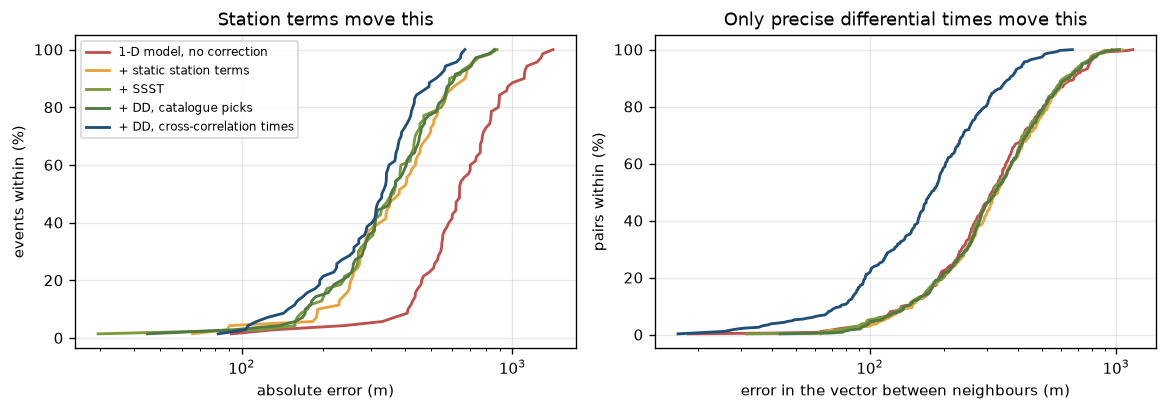

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(9.8, 3.5))
cols = ("#c0504d", "#e8a33d", "#7a9a3b", "#4f7942", "#1f4e79")
for (lab, M), c in zip(ladder, cols):
    e = np.sort(np.linalg.norm(M[:, :3] - truths[:, :3], axis=1))
    ax[0].plot(1000 * e, 100 * np.arange(1, len(e) + 1) / len(e), c=c, lw=1.7, label=lab)
    q = np.sort([np.linalg.norm((M[i, :3] - M[j, :3]) - (truths[i, :3] - truths[j, :3]))
                 for i, j in pairs])
    ax[1].plot(1000 * q, 100 * np.arange(1, len(q) + 1) / len(q), c=c, lw=1.7, label=lab)
ax[0].set(xscale="log", xlabel="absolute error (m)", ylabel="events within (%)",
          title="Station terms move this")
ax[1].set(xscale="log", xlabel="error in the vector between neighbours (m)",
          ylabel="pairs within (%)", title="Only precise differential times move this")
ax[0].legend(fontsize=7)
fig.tight_layout()
plt.show()


### What this predicts for the real data

**The two columns move independently, and each method touches only one of them.**

Static station terms cut the absolute error substantially and do nothing for the pairwise error
— if anything they make it marginally worse. That is arithmetic rather than disappointment: a
delay that is the same for every ray into a station is *already* common to both events of a
pair, so it cancels from their difference before any method is applied. Removing it improves
where the earthquakes are; it cannot improve where they are with respect to each other, and the
small step backwards is the estimated terms carrying a little noise of their own into every
event they touch.

Double difference does the opposite — and only when the differential times are precise. On
catalogue picks it achieves almost nothing, because differencing two arrivals each uncertain by
0.03 s gives a differential time uncertain by more than either one alone. Measured by
cross-correlation instead, at 0.003 s, the same code on the same pairs halves the pairwise error
and barely touches the absolute one.

**SSST sits between them**, as designed: letting a station's term depend on where the earthquake
was reaches a little of the structure a single constant cannot.

So the advice to leave with is not "relocate and the answer gets better". It is: **decide which
question you are asking.** Whether the seismicity sits above or below a given depth is an
*absolute* question, and it is answered by the velocity model and station terms. Whether the
events lie on a plane is a *relative* question, and it is answered by cross-correlation and
double difference. The two are bought with different currency, and neither purchase includes the
other.



## A.11 · Solving for the velocity model itself

A.9 put a number on the damage: locate with the wrong 1-D model and the 95 % ellipse holds the
truth far less than 95 % of the time. The reason was not that the ellipse was too small but that
the error was **bias** — every event pushed the same way — and an error bar computed from the
scatter of the residuals cannot see bias. A.10 then showed that station terms absorb the part of
that error which is fixed to each station, and that the part which is not stays.

The move we have not tried is the obvious one: stop treating the velocity model as a constant of
the problem and **solve for it too**. That is what VELEST does (Kissling, Ellsworth,
Eberhart-Phillips & Kradolfer 1994, [10.1029/93JB03138](https://doi.org/10.1029/93JB03138)), and
it is the direct ancestor of the tomography in session 5.

It cannot be done naively, for the reason that has run through this whole session, one level up:
**slow the model down and push every earthquake deeper, and the arrival times hardly change.**
Depth and layer velocity are coupled almost as tightly as depth and origin time were in A.5.


In [42]:
print(f"{'events pushed deeper by':>26}{'best velocity scaling':>24}{'rms (s)':>11}")
for push in (0.0, 0.2, 0.4, 0.6):
    best = (np.inf, None)
    for scale in np.arange(0.94, 1.0801, 0.01):
        mod = gl.GEY.copy()
        mod[:, 1:] *= scale
        tb = [gl.build(mod, ph, ZR, ZS, RR) for ph in ("P", "S")]
        rr = []
        for i, ((sta, t_obs, phase), tr) in enumerate(zip(obs, truths)):
            m = np.array([tr[0], tr[1], tr[2] + push, tr[3]])
            # the 3-D delay is removed first, so this cell isolates the depth-velocity
            # trade-off instead of re-measuring the structure of A.10
            dres = gl.residuals(sta, t_obs - DT[i], phase, tb, m)
            rr.append(dres - dres.mean())     # the origin time absorbs the constant
        val = float(np.sqrt(np.mean(np.concatenate(rr) ** 2)))
        if val < best[0]:
            best = (val, scale)
    print(f"{push:22.1f} km{best[1]:24.3f}{best[0]:13.4f}")
print("\nPush every earthquake deeper and let the model slow down to compensate, and the rms barely")
print("moves: the pair (depth, velocity) is far better determined than either one alone. But look")
print("at the rms column rather than the scaling column -- it does rise. The trade-off is severe,")
print("not exact, and a curvature that shallow is still a curvature. Whether it is enough to work")
print("with is a quantitative question, and the rest of this section answers it.")


   events pushed deeper by   best velocity scaling    rms (s)


                   0.0 km                   1.000       0.0295


                   0.2 km                   0.970       0.0297


                   0.4 km                   0.940       0.0302


                   0.6 km                   0.940       0.0318

Push every earthquake deeper and let the model slow down to compensate, and the rms barely
moves: the pair (depth, velocity) is far better determined than either one alone. But look
at the rms column rather than the scaling column -- it does rise. The trade-off is severe,
not exact, and a curvature that shallow is still a curvature. Whether it is enough to work
with is a quantitative question, and the rest of this section answers it.


### The one derivative we are missing

Everything else is already built. Geiger's method in A.3 needed one row of $G$ per pick, holding
the derivative of that pick's predicted time with respect to each unknown. We need to widen those
rows. Step by step:

**Step 1 — name the new unknowns.** Until now each event carried four, $m = (x, y, z, t_0)$, and
the velocity model carried none: it was a constant. Now let the layer velocities join the
unknowns. Call them $v_1 \dots v_L$, one per layer, $L$ layers in all. One difference from the
hypocentre unknowns drives everything that follows: **$x, y, z, t_0$ belong to one earthquake,
but $v_1 \dots v_L$ belong to every earthquake at once.**

**Step 2 — say what the new columns must contain.** $G$'s definition is unchanged: entry $(i, j)$
is how much prediction $i$ moves when unknown $j$ moves by one unit. So the new columns hold
$\partial T_i / \partial v_k$ — how much *this* pick's travel time changes if layer $k$ is made
one km/s faster.

**Step 3 — face the difficulty, and watch it disappear.** Speed up a layer and the ray does not
simply run faster along the same path: it *bends*, because the angle at which it crosses every
interface is set by the velocity contrast. It looks as though we need to know how the whole path
moves. We do not — and the reason is **Fermat's principle**. The path a wave actually takes is
the one whose travel time is *stationary*: shift the path a little and the time changes only at
second order. So a small change $\delta v_k$ alters the travel time twice over, directly (the
wave is faster where it already goes) and indirectly (the path moves), and the indirect term is
second order and drops out. **Hold the ray where it is and differentiate only the explicit $v$.**

**Step 4 — write the time as a sum over layers.** Let $L_k$ be the *length of the ray inside
layer $k$* — kilometres of path, not the thickness of the layer, and zero for a layer the ray
never enters. Then, since speed is constant inside a layer,

$$ T \;=\; \sum_{k=1}^{L} \frac{L_k}{v_k}. $$

**Step 5 — differentiate.** With the ray held fixed, $L_k$ does not depend on $v_k$, so every
term but one is constant and

$$ \boxed{\;\frac{\partial T}{\partial v_k} \;=\; -\,\frac{L_k}{v_k^{2}}\;} $$

That is the entire velocity kernel: one number per layer per pick, the path length in that layer
over minus the velocity squared. It is negative because a faster layer can only make a wave
arrive sooner.

**Step 6 — get $L_k$.** Inside layer $k$ the ray makes an angle $i_k$ with the vertical, and
Snell's law holds $p = \sin i_k / v_k$ constant along the path — $p$ is the ray parameter A.3
already used for $\partial T/\partial x$. A layer of thickness $h_k$ that the ray crosses
therefore costs $L_k = h_k/\cos i_k = h_k/\sqrt{1 - p^2 v_k^2}$. A head wave is the same
arithmetic plus its horizontal run along the top of the refracting layer. `gl.rays` returns these
lengths for many picks at once; it is the same travel-time calculation as A.1, asked for the
path rather than only the time.

The derivative is worth checking rather than trusting, and a finite difference does it in three
lines.


In [43]:
tops = np.r_[-2.0, np.cumsum(gl.GEY[:-1, 0]), np.cumsum(gl.GEY[:, 0])[-1]]   # interface depths
v_true = gl.GEY[:, 1].copy()                                    # 7 layers, the top one extended up
_zs = rng.uniform(0.3, 6.0, 2000)
_zr = rng.uniform(float(_all.z.min()), float(_all.z.max()), 2000)
_r = rng.uniform(0.5, 14.0, 2000)
_t, _L, _p, _head = gl.rays(tops, v_true, _zs, _r, _zr)
print(f"{len(_t)} rays: {100 * _head.mean():.0f}% arrive as head waves, "
      f"path lengths sum back to the travel time to {np.abs((_L / v_true).sum(1) - _t).max():.1e} s")
print(f"\n{'layer':>6}{'top km':>9}{'v km/s':>9}{'mean L km':>11}"
      f"{'dT/dv analytic':>17}{'finite difference':>19}")
for k in range(len(v_true)):
    vp, vm = v_true.copy(), v_true.copy()
    vp[k] += 1e-4
    vm[k] -= 1e-4
    fd = (gl.rays(tops, vp, _zs, _r, _zr)[0] - gl.rays(tops, vm, _zs, _r, _zr)[0]) / 2e-4
    an = -_L[:, k] / v_true[k] ** 2
    print(f"{k + 1:>6}{tops[k]:9.2f}{v_true[k]:9.2f}{_L[:, k].mean():11.3f}"
          f"{an.mean():17.5f}{fd.mean():19.5f}")
print("\nThe two columns agree, so -L/v^2 is the derivative and Fermat's principle earned its keep:")
print("nobody had to work out how the ray bends.")


2000 rays: 8% arrive as head waves, path lengths sum back to the travel time to 0.0e+00 s

 layer   top km   v km/s  mean L km   dT/dv analytic  finite difference
     1    -2.00     4.43      3.787         -0.19295           -0.19295
     2     1.50     5.12      2.925         -0.11159           -0.11159
     3     3.00     5.47      1.489         -0.04978           -0.04978
     4     4.25     5.58      0.614         -0.01971           -0.01971
     5     6.00     5.62      0.000          0.00000            0.00000
     6     8.00     5.86      0.000          0.00000            0.00000
     7    21.00     7.90      0.000          0.00000            0.00000

The two columns agree, so -L/v^2 is the derivative and Fermat's principle earned its keep:
nobody had to work out how the ray bends.


### One matrix for the whole catalogue

Now stack. Let there be $E$ events, $L$ layers and $N$ picks in total. One row per pick, as
always. The unknown vector is

$$ \Delta m \;=\; (\underbrace{\Delta x_1, \Delta y_1, \Delta z_1, \Delta t_{0,1}, \;\dots\;,
   \Delta x_E, \Delta y_E, \Delta z_E, \Delta t_{0,E}}_{4E \text{ hypocentre unknowns}},
   \; \underbrace{\Delta v_1, \dots, \Delta v_L}_{L \text{ velocities}} ), $$

so $G$ is $N \times (4E + L)$ and the system is still $G\,\Delta m = r$, solved exactly as A.3
solved it. What has changed is the *shape* of $G$, and the shape is the whole story:

- the **hypocentre columns are block diagonal**. A pick of event 3 says nothing about where event
  7 was, so its four hypocentre entries sit in event 3's block and the rest of that stripe is
  zero. Locating events one at a time, as every earlier section did, is exactly the statement
  that this block is all there is.
- the **velocity columns are dense**. Every pick of every event constrains every layer its ray
  passes through. These columns are the only thing connecting one earthquake to another, and
  that is why the problem has to be solved for the whole catalogue at once: one event cannot
  separate its own depth from the velocity above it, but a thousand events at different depths
  and distances, sharing one model, can.

Two practical points, both of which VELEST makes and both of which matter more than they look.

**Damping is per class, not global.** A.4 added $\lambda$ to the diagonal of $G^{\mathsf T}G$ to
stop the step overshooting. One $\lambda$ will not do here, because the columns have wildly
different leverage: moving one event's depth changes that event's picks only, while moving one
layer velocity changes *every* prediction in the catalogue. So the velocity block gets its own,
much heavier ridge — in VELEST, typically a hundred times the hypocentre one.

**A step that makes the fit worse is not taken**: each step is tried, halved if the rms rises, and
abandoned if halving does not help. That is A.4's trust region again, at catalogue scale.

Station terms are a third block of the same matrix — one column each, one entry per pick — and
VELEST solves for them here too. We leave them out below so that the experiment measures the
velocity model and nothing else; A.10 already measured what station terms buy.


In [44]:
def couple(tops, v0, ev0, sta, ev_of, st_of, t_obs, n_iter=25, fit_v=True, free=None,
           damp=(0.01, 0.01, 0.01, 1.0), vstep=0.3, zmin=-1.5):
    """Solve every hypocentre and every layer velocity in ONE damped least-squares system.

    `ev_of[i]` and `st_of[i]` say which event and which station pick `i` belongs to; `free`
    marks the layers allowed to move.  Returns the model, the hypocentres and the rms history.
    """
    v, ev = np.array(v0, float), np.array(ev0, float)
    n_ev, n_l, n_pick = len(ev), len(v), len(t_obs)
    free = np.ones(n_l, bool) if free is None else np.asarray(free, bool)
    n_var = 4 * n_ev + n_l
    lam = np.r_[np.tile(np.array([damp[0], damp[0], damp[1], damp[2]]), n_ev),
                np.full(n_l, damp[3])]
    hold = np.r_[np.zeros(4 * n_ev, bool), ~free if fit_v else np.ones(n_l, bool)]

    def predict(v_, ev_):
        dx, dy = ev_[ev_of, 0] - sta[st_of, 0], ev_[ev_of, 1] - sta[st_of, 1]
        d = np.maximum(np.hypot(dx, dy), 1e-3)
        t, L, p, head = gl.rays(tops, v_, ev_[ev_of, 2], d, sta[st_of, 2])
        return t + ev_[ev_of, 3], (dx, dy, d, L, p, head)

    rms = []
    for _ in range(n_iter):
        t_pred, (dx, dy, d, L, p, head) = predict(v, ev)
        r = t_obs - t_pred
        rms.append(float(np.sqrt(np.mean(r ** 2))))
        # --- the four hypocentre columns, exactly as in A.3
        j = np.clip(np.searchsorted(tops, ev[ev_of, 2], side="right") - 1, 0, n_l - 1)
        eta = np.sqrt(np.maximum(1.0 / v[j] ** 2 - p ** 2, 0.0))
        eta = np.where(head, -1.0, np.sign(ev[ev_of, 2] - sta[st_of, 2])) * eta
        G_hyp = np.column_stack([p * dx / d, p * dy / d, eta, np.ones_like(d)])
        G_vel = -L / v[None, :] ** 2                      # ... and the new ones
        col = np.column_stack([4 * ev_of, 4 * ev_of + 1, 4 * ev_of + 2, 4 * ev_of + 3,
                               np.tile(np.arange(4 * n_ev, n_var), (n_pick, 1))])
        G = csr_matrix((np.column_stack([G_hyp, G_vel]).ravel(),
                       (np.repeat(np.arange(n_pick), 4 + n_l), col.ravel())),
                       shape=(n_pick, n_var))
        A, b = (G.T @ G).toarray(), G.T @ r
        A[hold, :] = 0.0
        A[:, hold] = 0.0
        b[hold] = 0.0
        A[np.arange(n_var), np.arange(n_var)] += lam      # one ridge per class of unknown
        A[hold, hold] = 1.0
        step = np.linalg.solve(A, b)
        # --- take the step only if it helps; halve it if it does not
        best = (rms[-1], ev, v)
        for shrink in (1.0, 0.5, 0.25, 0.1):
            ev_try = ev.copy()
            ev_try[:, :4] += shrink * step[:4 * n_ev].reshape(n_ev, 4)
            ev_try[:, 2] = np.clip(ev_try[:, 2], zmin, None)
            v_try = v + np.where(free, shrink * np.clip(step[4 * n_ev:], -vstep, vstep), 0.0)
            q = float(np.sqrt(np.mean((t_obs - predict(v_try, ev_try)[0]) ** 2)))
            if q < best[0]:
                best = (q, ev_try, v_try)
                break
        _, ev, v = best
    rms.append(float(np.sqrt(np.mean((t_obs - predict(v, ev)[0]) ** 2))))
    return dict(v=v, ev=ev, rms=np.array(rms))


### The experiment

Plant a catalogue in the GEY model — the same real station geometry, at real elevations, that
every section has used — and then hand the solver **GIL7**, the wrong model from A.9. Two runs:
hypocentres only, which is every earlier section of this notebook, and hypocentres *and*
velocities together. The truth is planted, so for once the word "accuracy" means something.


In [45]:
N_V, SIG_V = 300, 0.020
v_wrong = gl.GIL7[np.clip(np.searchsorted(np.r_[0.0, np.cumsum(gl.GIL7[:-1, 0])],
                                          tops[:-1], side="right") - 1, 0, None), 1]
r_v = np.random.default_rng(29)
sta_v = _all[["x", "y", "z"]].to_numpy()
ev_true = np.column_stack([r_v.uniform(-7, 7, N_V), r_v.uniform(-7, 7, N_V),
                           np.clip(r_v.gamma(3.0, 0.62, N_V) - 0.1, 0.25, 9.0),
                           np.zeros(N_V)])
ev_of, st_of = [], []
for i in range(N_V):
    near_v = np.where(np.hypot(sta_v[:, 0] - ev_true[i, 0], sta_v[:, 1] - ev_true[i, 1]) <= 12.0)[0]
    ev_of.append(np.full(len(near_v), i))
    st_of.append(near_v)
ev_of, st_of = np.concatenate(ev_of), np.concatenate(st_of)
_d = np.maximum(np.hypot(ev_true[ev_of, 0] - sta_v[st_of, 0],
                         ev_true[ev_of, 1] - sta_v[st_of, 1]), 1e-3)
t_clean, L_true, _, _ = gl.rays(tops, v_true, ev_true[ev_of, 2], _d, sta_v[st_of, 2])
t_pick = t_clean + r_v.normal(0, SIG_V, len(t_clean))

ray_km = L_true.sum(0)                       # how far the rays actually travel in each layer
free_layer = ray_km >= 0.01 * ray_km.sum()   # only invert where the data have been
print(f"{N_V} events, {len(t_pick)} picks, {SIG_V * 1000:.0f} ms reading noise, "
      f"depths {ev_true[:, 2].min():.2f}-{ev_true[:, 2].max():.2f} km\n")
print(f"{'layer':>6}{'depth range km':>18}{'ray km':>10}{'% of all':>10}{'inverted?':>11}")
for k in range(len(v_true)):
    print(f"{k + 1:>6}{tops[k]:8.2f} to{tops[k + 1]:7.2f}{ray_km[k]:10.0f}"
          f"{100 * ray_km[k] / ray_km.sum():10.1f}{'yes' if free_layer[k] else 'no':>11}")
print("\nThe rays go where the earthquakes are. Below the deepest ray the data say nothing at all,")
print("so those layers are held at their starting values rather than invented.")


300 events, 17012 picks, 20 ms reading noise, depths 0.25-5.04 km

 layer    depth range km    ray km  % of all  inverted?
     1   -2.00 to   1.50     84826      65.9        yes
     2    1.50 to   3.00     39368      30.6        yes
     3    3.00 to   4.25      4162       3.2        yes
     4    4.25 to   6.00       417       0.3         no
     5    6.00 to   8.00         0       0.0         no
     6    8.00 to  21.00         0       0.0         no
     7   21.00 to  81.00         0       0.0         no

The rays go where the earthquakes are. Below the deepest ray the data say nothing at all,
so those layers are held at their starting values rather than invented.


In [46]:
ev_start = ev_true.copy()
ev_start[:, :2] += r_v.normal(0, 0.5, (N_V, 2))
ev_start[:, 2] = np.clip(ev_true[:, 2] + r_v.normal(0, 0.5, N_V), 0.25, None)

runs = {}
for label, v0, fit in [("GEY (the truth), hypocentres only", v_true, False),
                       ("GIL7 (wrong), hypocentres only", v_wrong, False),
                       ("GIL7 (wrong), + velocity model", v_wrong, True)]:
    runs[label] = couple(tops, v0, ev_start, sta_v, ev_of, st_of, t_pick,
                         n_iter=25, fit_v=fit, free=free_layer)

print(f"{'':36}{'rms s':>8}{'med |dh|':>10}{'p90 |dh|':>10}{'depth bias':>12}"
      f"{'depth sd':>10}{'t0 bias':>9}")
for label, R in runs.items():
    dh = np.hypot(R["ev"][:, 0] - ev_true[:, 0], R["ev"][:, 1] - ev_true[:, 1])
    dz = R["ev"][:, 2] - ev_true[:, 2]
    print(f"{label:36}{R['rms'][-1]:8.4f}{np.median(dh):10.3f}{np.percentile(dh, 90):10.3f}"
          f"{dz.mean():+12.3f}{dz.std():10.3f}{R['ev'][:, 3].mean():+9.3f}")
print("\nkm and seconds. 'depth bias' is the mean signed depth error -- the number A.9 cared about,")
print("because it is bias and not scatter that an error bar cannot see.")
_b = runs["GIL7 (wrong), hypocentres only"]["ev"][:, 2] - ev_true[:, 2]
_a = runs["GIL7 (wrong), + velocity model"]["ev"][:, 2] - ev_true[:, 2]
print(f"\n{'layer':>6}{'GIL7 start':>13}{'recovered':>12}{'planted truth':>16}{'still wrong by':>17}")
for k in range(len(v_true)):
    mark = ("" if free_layer[k] else
            "   (no rays at all -- held)" if ray_km[k] == 0 else "   (too few rays -- held)")
    print(f"{k + 1:>6}{v_wrong[k]:13.2f}{runs['GIL7 (wrong), + velocity model']['v'][k]:12.2f}"
          f"{v_true[k]:16.2f}{runs['GIL7 (wrong), + velocity model']['v'][k] - v_true[k]:+17.2f}{mark}")

print(f"\nSolving for the model moved the depth bias from {_b.mean():+.3f} km to {_a.mean():+.3f} km,")
print(f"and the rms from {runs['GIL7 (wrong), hypocentres only']['rms'][-1]:.4f} s back down to "
      f"{runs['GIL7 (wrong), + velocity model']['rms'][-1]:.4f} s,")
print(f"which is where the {SIG_V * 1000:.0f} ms reading noise alone puts it.")


                                       rms s  med |dh|  p90 |dh|  depth bias  depth sd  t0 bias
GEY (the truth), hypocentres only     0.0193     0.031     0.061      -0.000     0.062   -0.000
GIL7 (wrong), hypocentres only        0.0383     0.090     0.191      +1.316     0.317   -0.472
GIL7 (wrong), + velocity model        0.0193     0.031     0.061      +0.003     0.064   -0.001

km and seconds. 'depth bias' is the mean signed depth error -- the number A.9 cared about,
because it is bias and not scatter that an error bar cannot see.

 layer   GIL7 start   recovered   planted truth   still wrong by
     1         3.20        4.43            4.43            -0.00
     2         4.50        5.12            5.12            -0.00
     3         4.80        5.49            5.47            +0.02
     4         5.51        5.51            5.58            -0.07   (too few rays -- held)
     5         6.21        6.21            5.62            +0.59   (no rays at all -- held)
     6         6

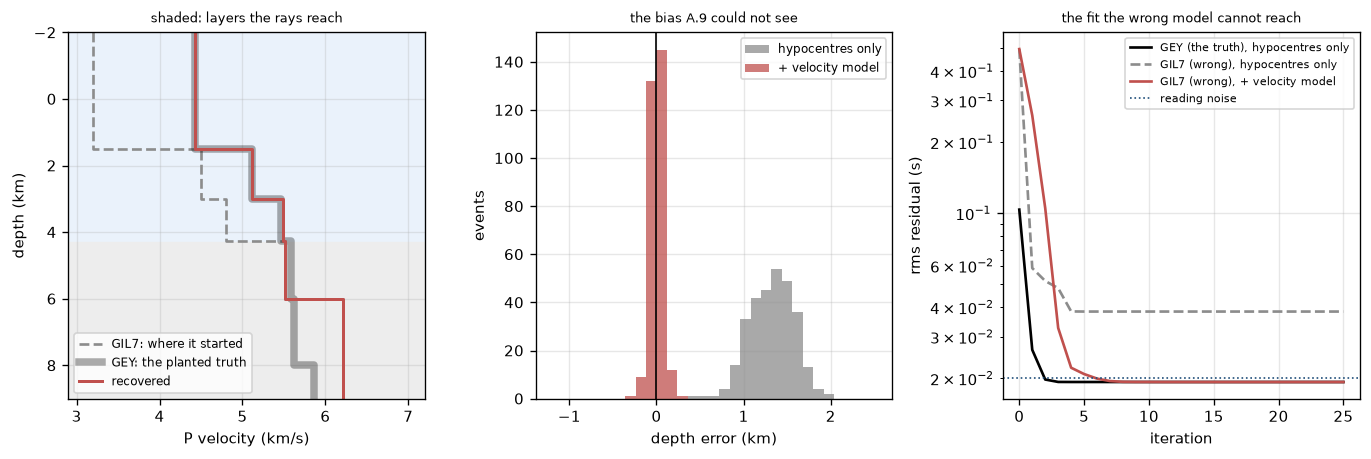

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.9))
R = runs["GIL7 (wrong), + velocity model"]


def step_model(a, v, **kw):
    a.step(np.repeat(v, 2), np.repeat(tops, 2)[1:-1], where="pre", **kw)


zmax = 9.0
ax[0].fill_betweenx([tops[0], zmax], 0, 1, transform=ax[0].get_yaxis_transform(),
                    color="0.93", zorder=0)
for k in range(len(v_true)):
    if free_layer[k]:
        ax[0].fill_betweenx([tops[k], min(tops[k + 1], zmax)], 0, 1, color="#eaf2fb",
                            transform=ax[0].get_yaxis_transform(), zorder=0)
step_model(ax[0], v_wrong, color="0.55", ls="--", lw=1.6, label="GIL7: where it started")
step_model(ax[0], v_true, color="k", lw=4.5, alpha=0.32, label="GEY: the planted truth")
step_model(ax[0], R["v"], color="#c0504d", lw=1.8, label="recovered")
ax[0].set(xlabel="P velocity (km/s)", ylabel="depth (km)", ylim=(zmax, tops[0]), xlim=(2.9, 7.2))
ax[0].legend(fontsize=7, loc="lower left")
ax[0].set_title("shaded: layers the rays reach", fontsize=8)

for label, c in [("GIL7 (wrong), hypocentres only", "0.55"),
                 ("GIL7 (wrong), + velocity model", "#c0504d")]:
    ax[1].hist(runs[label]["ev"][:, 2] - ev_true[:, 2], bins=np.arange(-1.2, 2.61, 0.12),
               color=c, alpha=0.75, label=label.split(", ")[1])
ax[1].axvline(0, color="k", lw=1)
ax[1].set(xlabel="depth error (km)", ylabel="events")
ax[1].legend(fontsize=7)
ax[1].set_title("the bias A.9 could not see", fontsize=8)

for label, c, ls in [("GEY (the truth), hypocentres only", "k", "-"),
                     ("GIL7 (wrong), hypocentres only", "0.55", "--"),
                     ("GIL7 (wrong), + velocity model", "#c0504d", "-")]:
    ax[2].plot(runs[label]["rms"], color=c, ls=ls, lw=1.6, label=label)
ax[2].axhline(SIG_V, color="#1f4e79", lw=1, ls=":", label="reading noise")
ax[2].set(xlabel="iteration", ylabel="rms residual (s)", yscale="log")
ax[2].legend(fontsize=6.5)
ax[2].set_title("the fit the wrong model cannot reach", fontsize=8)
plt.tight_layout()
plt.show()


### What it can and cannot do

**It works, and that was not a foregone conclusion.** The depth bias — the thing A.9 showed an
error bar cannot see — is gone, and the rms falls back to where the reading noise alone puts it.
The trade-off cell at the top of this section showed how nearly degenerate depth and velocity
are, so what breaks the degeneracy? **The catalogue.** One earthquake cannot separate its own
depth from the velocity above it: both simply delay its arrivals. Three hundred earthquakes at
different depths, recorded across a wide range of distances and sharing a single model, can —
because a layer velocity announces itself in the *slope* of travel time against distance, while a
depth announces itself mostly in the intercept. That is why the problem is solved for the whole
catalogue at once, and why the dense velocity columns are what make the matrix worth assembling.

**It only works where the rays go.** The layers below the deepest earthquake come out holding
GIL7's velocities exactly, because no datum ever touched them, and nothing in the fit complains:
a layer no ray visits cannot change a single prediction. The honest response is the one taken
above — freeze those layers rather than let the solver invent them — and that lesson carries
straight into session 5, where the same arithmetic meets a 3-D grid of mostly empty cells.

**What comes out is not the Earth.** The recovered model matches the planted one here only
because the planted Earth really was a stack of flat layers — which is the one reason "did it
recover the truth?" was a question we could ask. The real Earth is not, and then the coupled
inversion returns what Kissling et al. named a **minimum 1-D model**: the layered model that best
predicts the observed times. That is an excellent thing to locate earthquakes with and not a
description of the ground. A.10's 3-D anomalies are exactly the case where no 1-D model is
correct, and there the leftover goes into the station terms — which VELEST solves for in this
same matrix, as one more block of columns.

Hence the habit worth keeping: **a hypocentre is only as meaningful as the model it was computed
in**, so a relocated catalogue should be published with its velocity model and its datum. "Three
kilometres deep" is not a measurement until both are named.

The real VELEST does more than these forty lines: it solves for station delays and S velocities
too, handles shots with known origin times, and reports which layers the data actually
determined. Our travel times agree with the published Fortran to a few tens of microseconds per
pick once both are given the same rounded station coordinates.

> **Prediction for Part B.** On the real picks there is no planted truth, so the depth bias
> cannot be measured at all. What *can* be checked is its signature: fitting the model should
> move the catalogue systematically in depth while the rms falls only modestly. A large depth
> change bought with a small improvement in fit is the fingerprint of this trade-off.


## A.12 · Optional: a posterior without a grid

A.8 got the exact posterior by evaluating the likelihood at every node of a grid. That is
unimprovable in accuracy and hopeless in cost: it scales as the resolution to the power of the
number of unknowns, so four unknowns is already a quarter of a million evaluations for **one**
earthquake, and nobody runs it on a catalogue.

The machine-learning answer to "I cannot evaluate everywhere" is **variational inference**:
instead of mapping the distribution, carry a set of samples and move them until they are
distributed like it. **Stein variational gradient descent** (SVGD) does this with a cloud of
particles and two forces:

1. each particle is pushed in the direction that increases $\log p$, which pulls the cloud
   towards high probability;
2. each particle is pushed away from its neighbours through a kernel, which stops them all
   collapsing onto the single best point.

Gradient descent is force 1 alone, and it gives you a point estimate. Adding force 2 is what
turns the same gradient into a description of the whole distribution.

**And we already have the gradient.** For Gaussian errors,

$$\nabla_{\mathbf m} \log p \;=\; \frac{1}{\sigma^{2}}\,\mathbf{G}^{\mathsf T}\mathbf{r},$$

which is $\mathbf{G}$ and $\mathbf{r}$ — the identical two objects Geiger's method builds in
A.3. Nothing here needs automatic differentiation, a neural network, or any training: ray
theory hands us the analytic derivatives, and this section simply uses them a second way.
Gauss–Newton multiplies $\mathbf{G}^{\mathsf T}\mathbf{r}$ by
$(\mathbf{G}^{\mathsf T}\mathbf{G})^{-1}$ and takes one long step to a point; SVGD scales it and
nudges a cloud. Same ingredients, different question asked of them.

One practical note, because it is the part that bites. The raw gradient has units of
1/(km · s²) and is enormous, so a plain step size diverges instantly. We work in coordinates
**whitened by the formal covariance**, where one unit is one formal standard deviation in each
direction, and let AdaGrad set the rest. Preconditioning like this is not a trick specific to
SVGD; it is the same idea as damping in A.4, arriving for the same reason.


In [48]:
# Self-contained: this repeats A.8's single earthquake so the section stands on its own.
sta8, t8, ph8, _ = gl.observe(TRUTH, st, tabs, noise=0.03, seed=3)
out8 = gl.locate(sta8, t8, ph8, tabs, x0=[0.0, 0.0, 5.0, 0.0])
sig8 = float(np.sqrt(np.sum(out8["res"] ** 2) / (out8["n"] - 4)))
C8 = np.asarray(gl.ellipse(out8))
L8 = np.linalg.cholesky(C8)                  # whitening: one unit = one formal standard deviation


def grad_logp(m):
    """The gradient of the log posterior: G-transpose r over sigma squared, and nothing else."""
    t, G = jacobian(m, sta8, ph8, tabs)
    return G.T @ (t8 - t - m[3]) / sig8 ** 2


def svgd(centre, n=200, steps=300, lr=0.25, seed=0):
    """Stein variational gradient descent in whitened coordinates."""
    r = np.random.default_rng(seed)
    U = r.normal(0, 1, (n, 4))               # start as a unit ball around the point estimate
    acc = np.zeros_like(U)                   # AdaGrad accumulator
    for _ in range(steps):
        M = centre + U @ L8.T
        Gl = np.array([L8.T @ grad_logp(m) for m in M])
        d2 = np.sum((U[:, None, :] - U[None, :, :]) ** 2, axis=2)
        h = np.median(d2) / np.log(n + 1) + 1e-12              # the usual median heuristic
        K = np.exp(-d2 / h)
        phi = (K @ Gl                                          # 1. towards high probability
               + (2.0 / h) * (K.sum(axis=1)[:, None] * U - K @ U)) / n   # 2. apart from each other
        acc = acc + phi ** 2
        U = U + lr * phi / (1e-8 + np.sqrt(acc))
    return centre + U @ L8.T


t0 = time.time()
Pg = gl.posterior(sta8, t8, ph8, tabs, out8["m"], half=0.9, step=0.03, sigma=sig8)
p3g = Pg["p"]
margg = (p3g.sum(axis=(0, 1)), p3g.sum(axis=(0, 2)), p3g.sum(axis=(1, 2)))
grid8 = np.array([np.sqrt(np.sum(g ** 2 * m) - np.sum(g * m) ** 2)
                  for g, m in zip((Pg["x"], Pg["y"], Pg["z"]), margg)])
t_grid = time.time() - t0
print(f"the A.8 grid posterior: {p3g.size:,} likelihood evaluations   [{t_grid:.1f} s]\n")

print(f"{'':28}{'x':>9}{'y':>9}{'z':>9}   (standard deviation, km)")
print(f"{'grid posterior':28}{grid8[0]:9.4f}{grid8[1]:9.4f}{grid8[2]:9.4f}")
parts = {}
for n in (60, 200, 800):
    t0 = time.time()
    X = svgd(out8["m"], n=n)
    parts[n] = X
    sd = X[:, :3].std(axis=0)
    print(f"{'SVGD, ' + str(n) + ' particles':28}{sd[0]:9.4f}{sd[1]:9.4f}{sd[2]:9.4f}"
          f"   {sd[2] / grid8[2]:5.2f} of the grid width   [{time.time() - t0:.1f} s]")
print("\nThe particles reproduce the posterior's width, and they approach it from below: with too")
print("few of them the repulsion has too few neighbours to work against and the cloud is too")
print("tight. Under-dispersion at small particle counts is a known property of SVGD, not a bug in")
print("this implementation, and it is the thing to check before trusting any result from it.")


the A.8 grid posterior: 226,981 likelihood evaluations   [0.7 s]

                                    x        y        z   (standard deviation, km)
grid posterior                 0.0982   0.0879   0.2444


SVGD, 60 particles             0.0831   0.0744   0.2057    0.84 of the grid width   [1.0 s]


SVGD, 200 particles            0.0894   0.0800   0.2218    0.91 of the grid width   [3.5 s]


SVGD, 800 particles            0.0940   0.0841   0.2347    0.96 of the grid width   [16.7 s]

The particles reproduce the posterior's width, and they approach it from below: with too
few of them the repulsion has too few neighbours to work against and the cloud is too
tight. Under-dispersion at small particle counts is a known property of SVGD, not a bug in
this implementation, and it is the thing to check before trusting any result from it.


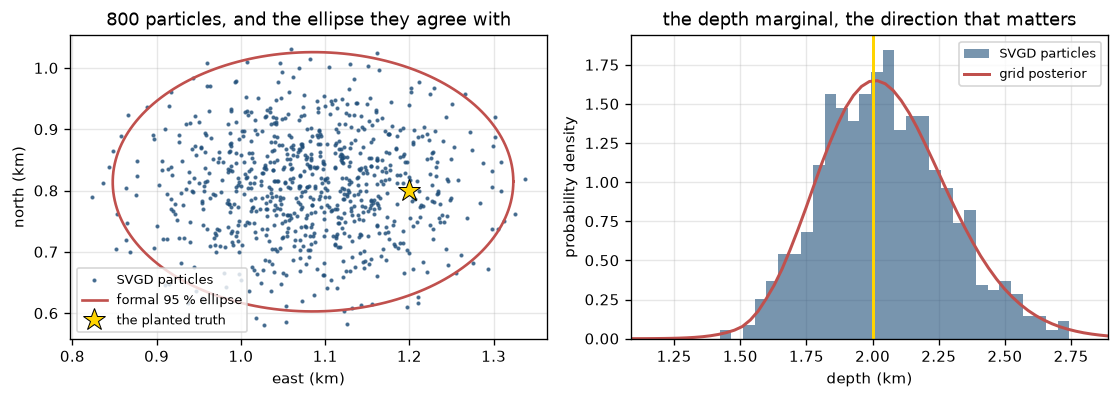

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.4))
X = parts[800]
th = np.linspace(0, 2 * np.pi, 200)
Lp = np.linalg.cholesky(C8[:2, :2] * 5.991)
e = (Lp @ np.vstack([np.cos(th), np.sin(th)])) + out8["m"][:2, None]
ax[0].plot(X[:, 0], X[:, 1], ".", ms=3, c="#1f4e79", alpha=0.7, label="SVGD particles")
ax[0].plot(e[0], e[1], "-", c="#c0504d", lw=1.6, label="formal 95 % ellipse")
ax[0].plot(*TRUTH[:2], "*", ms=14, mfc="#ffd400", mec="k", mew=0.6, label="the planted truth")
ax[0].set(xlabel="east (km)", ylabel="north (km)", title="800 particles, and the ellipse they agree with")
ax[0].legend(fontsize=7.5)

ax[1].hist(X[:, 2], bins=30, density=True, color="#1f4e79", alpha=0.6, label="SVGD particles")
ax[1].plot(Pg["z"], margg[2] / np.trapezoid(margg[2], Pg["z"]), c="#c0504d", lw=1.8,
           label="grid posterior")
ax[1].axvline(TRUTH[2], c="#ffd400", lw=1.8)
ax[1].set(xlabel="depth (km)", ylabel="probability density", xlim=(Pg["z"][0], Pg["z"][-1]),
          title="the depth marginal, the direction that matters")
ax[1].legend(fontsize=7.5)
fig.tight_layout()
plt.show()


### Where this sits in the literature, and what it does not fix

This is **HypoSVI** (Smith et al. 2021, [10.1093/gji/ggab309](https://doi.org/10.1093/gji/ggab309)),
reduced to its core. That paper pairs SVGD with a neural travel-time model so that it can run in
a genuinely 3-D velocity field, but that is a choice about the *forward model* and not a
requirement of the method — as the cell above shows, the gradients can come straight from ray
theory, the way every locator in this session computes them.

**SPIDER** (Ross et al. 2026, [10.1029/2025JB032769](https://doi.org/10.1029/2025JB032769)) takes
the same Bayesian stance to the *differential* problem of A.10, at catalogue scale, and it is
worth knowing what changes and what does not. The forward model is unchanged — double-difference
residuals from travel times. Two things do change. The sampler becomes Stochastic Gradient
Langevin Dynamics rather than SVGD, mini-batched and spread over GPUs, so that millions of
hypocentre parameters can be sampled jointly. And — the part that is statistics rather than
computation — the *likelihood* changes: differencing arrivals that share an event makes the
residuals correlated, so the covariance is not diagonal, and a method that assumes it is will
report error bars that are too small. Our own B.6-style argument, that differencing two picks
each uncertain by $\sigma$ gives $\sigma\sqrt2$, is the diagonal of exactly that matrix; SPIDER's
point is that the off-diagonal terms matter too.

**And now the caution, which is the reason this section is Optional rather than triumphant.**
Everything here is a better description of the posterior *given the velocity model*. A.9 showed
that the velocity model is what actually decides accuracy, and that no amount of care with the
likelihood detects a bias shared by every station. A particle cloud around a biased answer is a
sharper picture of the wrong place. That is worth stating plainly because it generalises well
past this session: **a more expressive model of the uncertainty is not a substitute for checking
whether the assumptions were right**, and the only tool in this notebook that checked those was
the coverage test, which needed a planted truth to run.


## A.13 · What Part A established

Everything above was measured in a world whose answer we set, which is the only place these
claims can be tested. Each one is a prediction about what the real 2016 Geysers picks will do,
and Part B checks them one by one.

| # | established in the planted world | what Part B should therefore find |
|---|---|---|
| 1 | Locating is linear least squares, relinearised. Plain Gauss–Newton breaks down from a poor start; damping fixes it | the production locator needs a coarse search to seed it |
| 2 | The worst-determined direction is almost pure depth, and a station closer than the focal depth is what breaks the trade-off | depth is the fragile number, and the field's dense network is what makes it usable |
| 3 | With a tenth of picks corrupted, the **loss** moves the answer several-fold; the **optimiser** does not | a robust loss is the largest single rung of the improvement ladder |
| 4 | A robust loss helps the median and the tail alike; **declared pick weights** leave the median almost untouched and cut the tail sharply | the analyst's own weight codes should act on the badly-recorded events and barely move the typical one |
| 5 | The formal ellipse, the bootstrap and the exact posterior agree in width but not in the tails | the catalogue's quoted errors should be treated as optimistic |
| 6 | A wrong velocity model destroys coverage — 95 % nominal, a few per cent actual — almost entirely through a **depth bias** | changing the velocity model should move the whole catalogue in depth while leaving rms nearly alone |
| 7 | Station terms recover planted delays and improve *relative* position; they do nothing for the absolute shift | station terms should transfer to events they were not fitted on |
| 8 | Double difference on catalogue-precision picks adds little; on cross-correlation times it is transformative | our DD on catalogue times should sharpen only modestly — the rest waits for session 6, template matching |
| 9 | Depth and velocity trade off severely but not exactly. Solving for both together, over a whole catalogue, removes a planted kilometre of depth bias — but only in the layers the rays reach | fitting the velocity model to the real picks should move the catalogue systematically in depth while the rms improves only modestly |

### The two words to keep apart

**Precision** is how tightly repeated measurements agree; the ellipse, the bootstrap and the
posterior all estimate it, and here they were all roughly right. **Accuracy** is how close you
are to the truth, and *nothing in the data measures it*, because a bias shared by every station
leaves no trace in the residuals. A relocated cluster can be sharp and wrong at the same time.

That is why the single most useful habit in this subject is to ask, of any published hypocentre:
what velocity model was it made with, and what would happen to it under a different one?


### What actually controls an earthquake location

Eight things decide where an earthquake ends up, and this session measured all of them. The
table below is assembled from the results above rather than retyped, so every number is one you
have already watched being produced.

Read it as an inventory rather than a league table: each row comes from its own experiment, with
its own events and its own noise, so the magnitudes are indicative and not a controlled
comparison between rows. What the table *is* good for is seeing that none of these factors is
negligible, and that they are not all the same kind of thing.


In [50]:
rows = [
    ("the velocity model",
     f"right -> wrong (GIL7)",
     f"{1000 * abs(err_w[:, 2].mean() - err_r[:, 2].mean()):.0f} m of depth bias, "
     f"and 95 % coverage becomes {100 * cov_w:.0f} %"),
    ("the loss function",
     "least squares -> robust",
     f"{1000 * np.median(res['L2 (least squares)']):.0f} -> "
     f"{1000 * np.median(res['RANSAC + refit']):.0f} m"),
    ("how many picks",
     f"{min(by_picks)} -> {max(by_picks)} picks",
     f"{by_picks[min(by_picks)]:.0f} -> {by_picks[max(by_picks)]:.0f} m"),
    ("where the picks are",
     f"azimuthal gap {min(by_gap):.0f}° -> {max(by_gap):.0f}°",
     f"{by_gap[min(by_gap)]:.0f} -> {by_gap[max(by_gap)]:.0f} m"),
    ("how well they are read",
     f"{min(k for k in by_noise if k):.2f} -> {max(by_noise):.2f} s reading error",
     f"{by_noise[min(k for k in by_noise if k)]:.0f} -> {by_noise[max(by_noise)]:.0f} m"),
    ("structure under the stations",
     "uncorrected -> station terms",
     f"{abs_error(M_none):.0f} -> {abs_error(M_static):.0f} m"),
    ("the quality label on each pick",
     "unweighted -> weighted",
     f"90th percentile {1000 * np.percentile(res['Huber'], 90):.0f} -> "
     f"{1000 * np.percentile(res['Huber + declared weights'], 90):.0f} m"),
    ("the optimiser",
     "undamped -> damped",
     f"{broke['plain Gauss-Newton']} of {n_try} starts broke down -> none"),
]
w = max(len(a) for a, _, _ in rows)
print(f"{'factor':<{w}}  {'varied from -> to':<38}  effect on the location")
print("-" * (w + 68))
for a, b, c in rows:
    print(f"{a:<{w}}  {b:<38}  {c}")


factor                          varied from -> to                       effect on the location
--------------------------------------------------------------------------------------------------
the velocity model              right -> wrong (GIL7)                   924 m of depth bias, and 95 % coverage becomes 2 %
the loss function               least squares -> robust                 1364 -> 435 m
how many picks                  4 -> 20 picks                           3275 -> 212 m
where the picks are             azimuthal gap 179° -> 286°              370 -> 734 m
how well they are read          0.01 -> 0.06 s reading error            68 -> 390 m
structure under the stations    uncorrected -> station terms            638 -> 382 m
the quality label on each pick  unweighted -> weighted                  90th percentile 2420 -> 1570 m
the optimiser                   undamped -> damped                      81 of 300 starts broke down -> none


Two comments on that ranking, because it is the practical content of the session.

**The first row is different in kind from all the others, and that matters more than its size.**
Every other row describes something more or better data would improve: add stations, close the
gap, read the arrivals more carefully, use the quality flags. Several of them span a larger range
of metres than the velocity model does. But they are all *scatter* — they make individual answers
noisy, and averaging many earthquakes beats them down. The velocity model is *bias*: it moves
every event the same way, so averaging does not help and the residuals never reveal it. It sets
the accuracy; everything below it sets the precision.

There is exactly one way out, and it is A.11: widen the problem until the velocity model is an
unknown rather than a constant. That converts the bias into something the data can speak about —
and it buys that only where the rays go, and only up to a model that fits rather than a model
that is true.

**The optimiser is last for a reason.** It is the part that looks like the hard problem, and it
is the part that matters least once it works at all. A great deal of effort in this subject goes
into the top three rows and almost none into the bottom one, and that allocation is correct.


## Takeaways

**Machine learning**

- Non-linear least squares is linear least squares relinearised, so everything week 1 proved
  still holds — one iteration at a time.
- Damping is week 1's ridge with a different justification: there it encoded a prior about the
  model, here it encodes distrust of the linearisation.
- The SVD tells you which combinations of unknowns the data cannot separate, and no algorithm
  recovers what the geometry did not measure.
- When the residuals have a heavy tail, the loss function moves the answer further than any
  optimiser will; the objective and the algorithm are separate choices.
- A quality label attached to a datum before the fit is independent evidence, and it helps the
  worst cases far more than the typical one.
- An error bar computed from the fit describes the noise you assumed, not the model error you
  have — so a confidence region is a claim to be tested by counting how often it covers the
  truth, which is only possible where the truth was planted.
- When a systematic error cannot be estimated from the residuals, the move is to make it a
  parameter: the bias then becomes estimable, at the price of a near-degenerate direction that
  has to be damped, and of an answer that is only defined where the data reach.

**Seismology**

- An earthquake location has four unknowns, and depth is almost always the fragile one, because
  the origin time can absorb most of what moving the source down would do.
- What breaks that trade-off is geometry, not cleverness: one station closer than the focal
  depth, or an S arrival.
- A location is precise to a couple of hundred metres and accurate only to whatever the velocity
  model is wrong by, and the residuals will not tell you which you are looking at.
- A wrong velocity model expresses itself as a shift in depth that leaves the fit almost
  unchanged — unless you have S picks, which is the cheapest check available.
- Station terms fix where earthquakes are; precise differential times fix where they are
  relative to each other; neither purchase includes the other.
- Solving for the layer velocities together with the hypocentres — VELEST's coupled inversion —
  removes the depth bias a wrong model causes, because the catalogue separates a velocity (a
  slope against distance) from a depth (an intercept) even though one earthquake cannot.
- What that returns is a *minimum 1-D model*: the layered model that best predicts the times,
  never the Earth, and unconstrained wherever no ray went.
- The shape of a relocated cluster can be interpreted, and its absolute position — above all its
  depth — cannot, without knowing the model and the datum it was measured from.


**[Part B](https://colab.research.google.com/github/AI4EPS/EPS207_Observational_Seismology/blob/main/docs/notebooks/02b_location_geysers.ipynb)** now takes every prediction in that table to the 2016
Geysers picks, where none of the answers are known — and where the final project starts.